# Projeto Final - Analise de eventos LHE

## Parte 1: Leitura do LHE para `pandas.DataFrame`

Este notebook e uma opcao de trabalho para estudantes. Ele nao contem codigo
pronto.

A ideia e usar cada celula de instrucao para pedir a um agente que gere o codigo
correspondente ao metodo **dataframe**. Depois, copie o codigo produzido pelo
agente para a celula vazia logo abaixo e execute no seu ambiente.

Arquivos da amostra:

- sinal: `../data/sinal.lhe.gz`;
- fundo: `../data/fundo.lhe.gz`.

Mantenha as respostas, tabelas, figuras e interpretacoes no proprio notebook.


## 0. Preparação no Google Colab

Antes de iniciar a análise, siga este fluxo no ambiente do Google Colab:

1. No GitHub, baixe o arquivo ZIP deste repositório (**Code → Download ZIP**) e baixe também o notebook desta tarefa que você vai executar.
2. Abra o notebook no Colab e use o painel **Arquivos** para fazer upload do arquivo `.ipynb` e do arquivo `.zip`. O ZIP deve ficar no mesmo ambiente de execução do notebook, como arquivo de dados.
3. Peça ao agente para gerar e executar um código que localize o ZIP enviado, descompacte o repositório no ambiente do Colab e entre na pasta extraída.
4. Em seguida, peça ao agente para gerar e executar um código que infle (descomprima com `gzip`) `data/sinal.lhe.gz` e `data/fundo.lhe.gz`, criando `data/sinal.lhe` e `data/fundo.lhe`. Mantenha os arquivos `.lhe.gz` originais.
5. Confirme com o agente que a pasta `data/` contém os dois arquivos compactados e as duas versões infladas antes de prosseguir.

Depois dessa preparação, peça ao agente os códigos de cada etapa indicada neste notebook e copie-os nas células de código correspondentes. Use a pasta extraída como diretório de trabalho e mantenha os caminhos relativos aos arquivos de dados.

In [2]:
!unzip /content/tarefa2-main.zip\n

unzip:  cannot find or open /content/tarefa2-main.zipn, /content/tarefa2-main.zipn.zip or /content/tarefa2-main.zipn.ZIP.


## 1. Leitura dos arquivos LHE

Objetivo: implementar a leitura das amostras de sinal e fundo usando o metodo
designado para este notebook: **Leitura do LHE para `pandas.DataFrame`**.

Nesta versao, a leitura deve produzir tabelas em `pandas.DataFrame`.

Peca ao agente para gerar codigo que leia os eventos e construa, no minimo, duas
tabelas:

- uma tabela de eventos, com amostra, indice do evento, `NUP`, escala
  e acoplamentos;
- uma tabela de particulas, com amostra, evento, PDG ID, `status`, maes, cor,
  `px`, `py`, `pz`, energia, massa, `pT`, `eta` e `phi`.

As etapas de validacao, histogramas e cutflow devem usar filtros, `groupby`,
agregacoes e merges de DataFrame sempre que possivel.

O codigo deve extrair, no minimo:

- cabecalho de cada evento;
- `NUP`;
- PDG ID;
- `status`;
- particulas-mae;
- `px`, `py`, `pz`, energia e massa.

Antes de implementar o parser, peça ao agente uma célula que abra `data/sinal.lhe.gz` e imprima o primeiro bloco completo entre `<event>` e `</event>`. Use essa inspeção para reconhecer o cabeçalho e as linhas das partículas.\n\nCole o codigo gerado na celula vazia abaixo.


In [3]:
import gzip

# Ajustando o caminho relativo conforme a estrutura do seu projeto
caminho_sinal = '../data/sinal.lhe.gz'

print("--- Inspecionando o primeiro evento do arquivo LHE ---\n")

with gzip.open(caminho_sinal, 'rt') as f:
    dentro_evento = False
    for linha in f:
        linha_limpa = linha.strip()
        
        if linha_limpa == '<event>':
            dentro_evento = True
            print(linha_limpa)
            continue
            
        if dentro_evento:
            print(linha_limpa)
            if linha_limpa == '</event>':
                break  # Interrompe o loop após o primeiro evento completo

--- Inspecionando o primeiro evento do arquivo LHE ---

<event>
8 1 +2.1101316e-02 0.1348444E+03 0.7546771E-02 0.1222323E+00
-4   -1    0    0    0  501 -0.00000000000E+00  0.00000000000E+00  0.12875516129E+03  0.12876142458E+03  0.12700000000E+01 0.  1.
4   -1    0    0  501    0  0.00000000000E+00 -0.00000000000E+00 -0.16520980844E+03  0.16521468974E+03  0.12700000000E+01 0. -1.
23    2    1    2    0    0 -0.96299308813E+02 -0.63959442510E+01  0.44076001733E+02  0.13691496633E+03  0.86536403295E+02 0.  9.
23    2    1    2    0    0  0.96299308813E+02  0.63959442510E+01 -0.80530648885E+02  0.15706114799E+03  0.94172999400E+02 0.  9.
-13    1    4    4    0    0  0.96631774437E+02 -0.18835201259E+02 -0.86588287733E+02  0.13111066842E+03  0.10566000000E+00 0. -1.
13    1    4    4    0    0 -0.33246562392E+00  0.25231145510E+02  0.60576388483E+01  0.25950479564E+02  0.10566000000E+00 0.  1.
-11    1    3    3    0    0 -0.58634394239E+02  0.15298108235E+02  0.64836535580E+02  0.887457

## 2a. Validacao preliminar das amostras

Objetivo: verificar se os arquivos foram lidos corretamente antes de interpretar fisica.

Peca ao agente para gerar codigo que, para sinal e fundo, calcule:

- numero total de eventos;
- distribuicao de `NUP`;
- resumo dos informacoes de normalizacao;
- canais partonicos iniciais a partir das particulas com `status = -1`;
- frequencia da topologia final esperada;
- lista ou contagem de eventos com campos invalidos ou topologia inesperada.

Depois de executar, escreva uma interpretacao curta: as duas amostras parecem consistentes?


In [4]:
import gzip
import pandas as pd
import numpy as np

def ler_lhe_para_pandas(caminho, nome_amostra):
    lista_eventos = []
    lista_particulas = []
    
    with gzip.open(caminho, 'rt') as f:
        dentro_evento = False
        id_evento = 0
        primeira_linha = False
        
        for linha in f:
            l = linha.strip()
            
            if l == '<event>':
                dentro_evento = True
                id_evento += 1
                primeira_linha = True
                continue
                
            if l == '</event>':
                dentro_evento = False
                continue
                
            if dentro_evento:
                valores = l.split()
                
                # Linha de cabeçalho do evento
                if primeira_linha:
                    # Formato: NUP, IDPRUP, XWGTUP, SCALUP, AQEDUP, AQCDUP
                    lista_eventos.append({
                        'amostra': nome_amostra,
                        'event_id': id_evento,
                        'NUP': int(valores[0]),
                        'peso': float(valores[2]),
                        'escala': float(valores[3]),
                        'aqed': float(valores[4]),
                        'aqcd': float(valores[5])
                    })
                    primeira_linha = False
                    
                # Linhas das partículas
                else:
                    # Formato: PDG, status, mother1, mother2, color1, color2, px, py, pz, E, m, vtim, spin
                    if len(valores) >= 11:
                        lista_particulas.append({
                            'amostra': nome_amostra,
                            'event_id': id_evento,
                            'pdg_id': int(valores[0]),
                            'status': int(valores[1]),
                            'mae1': int(valores[2]),
                            'mae2': int(valores[3]),
                            'cor1': int(valores[4]),
                            'cor2': int(valores[5]),
                            'px': float(valores[6]),
                            'py': float(valores[7]),
                            'pz': float(valores[8]),
                            'energia': float(valores[9]),
                            'massa': float(valores[10])
                        })
                        
    # Convertendo para DataFrame
    df_evt = pd.DataFrame(lista_eventos)
    df_part = pd.DataFrame(lista_particulas)
    
    # Cálculos vetorizados de cinemática
    px = df_part['px']
    py = df_part['py']
    pz = df_part['pz']
    p = np.sqrt(px**2 + py**2 + pz**2)
    
    df_part['pT'] = np.sqrt(px**2 + py**2)
    df_part['phi'] = np.arctan2(py, px)
    
    # Proteção para evitar avisos de divisão por zero na pseudo-rapidez (eta)
    with np.errstate(divide='ignore', invalid='ignore'):
        # eta = 0.5 * ln((|p| + pz) / (|p| - pz))
        df_part['eta'] = 0.5 * np.log((p + pz) / (p - pz))
        
    return df_evt, df_part

print("Processando arquivo de sinal...")
df_evt_sinal, df_part_sinal = ler_lhe_para_pandas('../data/sinal.lhe.gz', 'sinal')

print("Processando arquivo de fundo...")
df_evt_fundo, df_part_fundo = ler_lhe_para_pandas('../data/fundo.lhe.gz', 'fundo')

print("Concatenando as tabelas...")
df_eventos = pd.concat([df_evt_sinal, df_evt_fundo], ignore_index=True)
df_particulas = pd.concat([df_part_sinal, df_part_fundo], ignore_index=True)

print("\nSucesso! Variáveis 'df_eventos' e 'df_particulas' estão prontas para uso.")

print("="*50)
print("1. NÚMERO TOTAL DE EVENTOS")
print("="*50)
total_eventos = df_eventos.groupby('amostra').size()
print(total_eventos)
print("\n")

print("="*50)
print("2. DISTRIBUIÇÃO DE NUP (Número de partículas por evento)")
print("="*50)
distribuicao_nup = df_eventos.groupby(['amostra', 'NUP']).size()
print(distribuicao_nup)
print("\n")

print("="*50)
print("3. RESUMO DAS INFORMAÇÕES DE NORMALIZAÇÃO")
print("="*50)
# Seleciona colunas numéricas de interesse do cabeçalho do evento
colunas_norm = [c for c in ['peso', 'escala', 'aqed', 'aqcd'] if c in df_eventos.columns]
resumo_norm = df_eventos.groupby('amostra')[colunas_norm].describe()
print(resumo_norm)
print("\n")

print("="*50)
print("4. CANAIS PARTÔNICOS INICIAIS (status = -1)")
print("="*50)
particulas_iniciais = df_particulas[df_particulas['status'] == -1]
# Agrupa por evento e pega os PDG IDs, ordenando para evitar duplicatas do tipo (21, 2) e (2, 21)
canais_agrupados = particulas_iniciais.groupby(['amostra', 'event_id'])['pdg_id'].apply(lambda x: tuple(sorted(x))).reset_index()
canais_iniciais = canais_agrupados.groupby('amostra')['pdg_id'].value_counts()
print(canais_iniciais)
print("\n")

print("="*50)
print("5. FREQUÊNCIA DA TOPOLOGIA FINAL (status = 1)")
print("="*50)
particulas_finais = df_particulas[df_particulas['status'] == 1]
topologia_agrupada = particulas_finais.groupby(['amostra', 'event_id'])['pdg_id'].apply(lambda x: tuple(sorted(x))).reset_index()
topologia_final = topologia_agrupada.groupby('amostra')['pdg_id'].value_counts()
print(topologia_final)
print("\n")

print("="*50)
print("6. VALIDAÇÃO DE INTEGRIDADE (Eventos Inválidos)")
print("="*50)
# Verifica se o NUP reportado no cabeçalho bate com o número real de partículas lidas no evento
contagem_real = df_particulas.groupby(['amostra', 'event_id']).size().reset_index(name='contagem_lida')
validacao_nup = pd.merge(df_eventos[['amostra', 'event_id', 'NUP']], contagem_real, on=['amostra', 'event_id'])
eventos_divergentes = validacao_nup[validacao_nup['NUP'] != validacao_nup['contagem_lida']]

# Verifica se existem campos vazios (NaN) gerados por falha no parser
nans_eventos = df_eventos.isna().sum().sum()
nans_particulas = df_particulas.isna().sum().sum()

print(f"Eventos com divergência entre NUP e linhas lidas: {len(eventos_divergentes)}")
print(f"Campos nulos (NaN) na tabela de eventos: {nans_eventos}")
print(f"Campos nulos (NaN) na tabela de partículas: {nans_particulas}")

if not eventos_divergentes.empty:
    print("\nExemplos de divergência de NUP:")
    print(eventos_divergentes.head())


Processando arquivo de sinal...
Processando arquivo de fundo...
Concatenando as tabelas...

Sucesso! Variáveis 'df_eventos' e 'df_particulas' estão prontas para uso.
1. NÚMERO TOTAL DE EVENTOS
amostra
fundo    10000
sinal    10000
dtype: int64


2. DISTRIBUIÇÃO DE NUP (Número de partículas por evento)
amostra  NUP
fundo    6      10000
sinal    8      10000
dtype: int64


3. RESUMO DAS INFORMAÇÕES DE NORMALIZAÇÃO
            peso                                                        \
           count      mean           std       min       25%       50%   
amostra                                                                  
fundo    10000.0  0.000216  2.710641e-20  0.000216  0.000216  0.000216   
sinal    10000.0  0.021101  3.469620e-18  0.021101  0.021101  0.021101   

                              escala              ...      aqed            \
              75%       max    count        mean  ...       75%       max   
amostra                                           ...     

## 2b. Inventario de particulas e identificacao dos processos

Objetivo: construir uma tabela das particulas presentes no LHE.

Peca ao agente para gerar codigo que produza uma tabela separando particulas por PDG ID e `status`. A tabela deve mostrar:

- nome ou interpretacao da particula;
- `status`;
- numero total de ocorrencias;
- numero de eventos em que aparece;
- fracao dos eventos;
- papel fisico no processo.

Use a tabela e os cartoes do MadGraph registrados no LHE para responder:

- qual e o processo de sinal;
- qual e o processo de fundo;
- por que ambos podem produzir o mesmo estado final observavel.


In [5]:
import pandas as pd
from IPython.display import display

# Dicionário reduzido de PDG IDs para nomes de partículas
pdg_map = {
    1: 'd', -1: 'd~', 2: 'u', -2: 'u~', 3: 's', -3: 's~', 
    4: 'c', -4: 'c~', 5: 'b', -5: 'b~', 6: 't', -6: 't~',
    11: 'e-', -11: 'e+', 12: 've', -12: 've~',
    13: 'mu-', -13: 'mu+', 14: 'vmu', -14: 'vmu~',
    15: 'tau-', -15: 'tau+', 16: 'vtau', -16: 'vtau~',
    21: 'g', 22: 'gamma', 23: 'Z', 24: 'W+', -24: 'W-', 25: 'H'
}

def classificar_papel(status):
    if status == -1: return 'Feixe incidente (Estado inicial)'
    if status == 1:  return 'Observável (Estado final)'
    if status == 2:  return 'Ressonância intermediária'
    return 'Outro'

# Calculando total de eventos por amostra para obter as frações
totais = df_eventos.groupby('amostra').size()

# Agregando dados por amostra, id e status
inventario = df_particulas.groupby(['amostra', 'pdg_id', 'status']).agg(
    total_ocorrencias=('event_id', 'count'),
    num_eventos=('event_id', 'nunique')
).reset_index()

# Colunas derivadas
inventario['fracao_eventos'] = inventario.apply(lambda r: r['num_eventos'] / totais[r['amostra']], axis=1)
inventario['nome_particula'] = inventario['pdg_id'].map(pdg_map).fillna('ID: ' + inventario['pdg_id'].astype(str))
inventario['papel_fisico'] = inventario['status'].apply(classificar_papel)

# Organização final
colunas = ['amostra', 'nome_particula', 'pdg_id', 'status', 'total_ocorrencias', 'num_eventos', 'fracao_eventos', 'papel_fisico']
inventario = inventario[colunas].sort_values(by=['amostra', 'status', 'total_ocorrencias'], ascending=[True, True, False])

display(inventario.style.format({'fracao_eventos': '{:.2%}'}).hide(axis="index"))

amostra,nome_particula,pdg_id,status,total_ocorrencias,num_eventos,fracao_eventos,papel_fisico
fundo,u~,-2,-1,7663,7663,76.63%,Feixe incidente (Estado inicial)
fundo,u,2,-1,7663,7663,76.63%,Feixe incidente (Estado inicial)
fundo,c~,-4,-1,1375,1375,13.75%,Feixe incidente (Estado inicial)
fundo,c,4,-1,1375,1375,13.75%,Feixe incidente (Estado inicial)
fundo,d~,-1,-1,739,739,7.39%,Feixe incidente (Estado inicial)
fundo,d,1,-1,739,739,7.39%,Feixe incidente (Estado inicial)
fundo,s~,-3,-1,223,223,2.23%,Feixe incidente (Estado inicial)
fundo,s,3,-1,223,223,2.23%,Feixe incidente (Estado inicial)
fundo,mu+,-13,1,10000,10000,100.00%,Observável (Estado final)
fundo,e+,-11,1,10000,10000,100.00%,Observável (Estado final)


### Respostas:
1. pp -> ZZ -> e+e-mu+mu-
2. pp -> e+e-mu+mu-
3. Há multiplos canais para gerar este estado final.

## 3a. Variaveis cinematicas por particula

Objetivo: construir histogramas de `pT`, `eta` e `phi` para particulas finais visiveis.

Peca ao agente para gerar codigo que selecione particulas com `status = 1`, remova neutrinos e construa histogramas comparando sinal e fundo para cada especie relevante.

Intervalos sugeridos:

- `pT`: 0 a 100 GeV;
- `eta`: -3 a +3;
- `phi`: -pi a +pi.

Os histogramas devem informar:

- numero de entradas;
- numero e fracao de eventos representados;
- underflow;
- overflow;
- incerteza estatistica por bin.

Salve as figuras em `../resultados/graficos/`.


Salvo: ../resultados/graficos/hist_pT.png


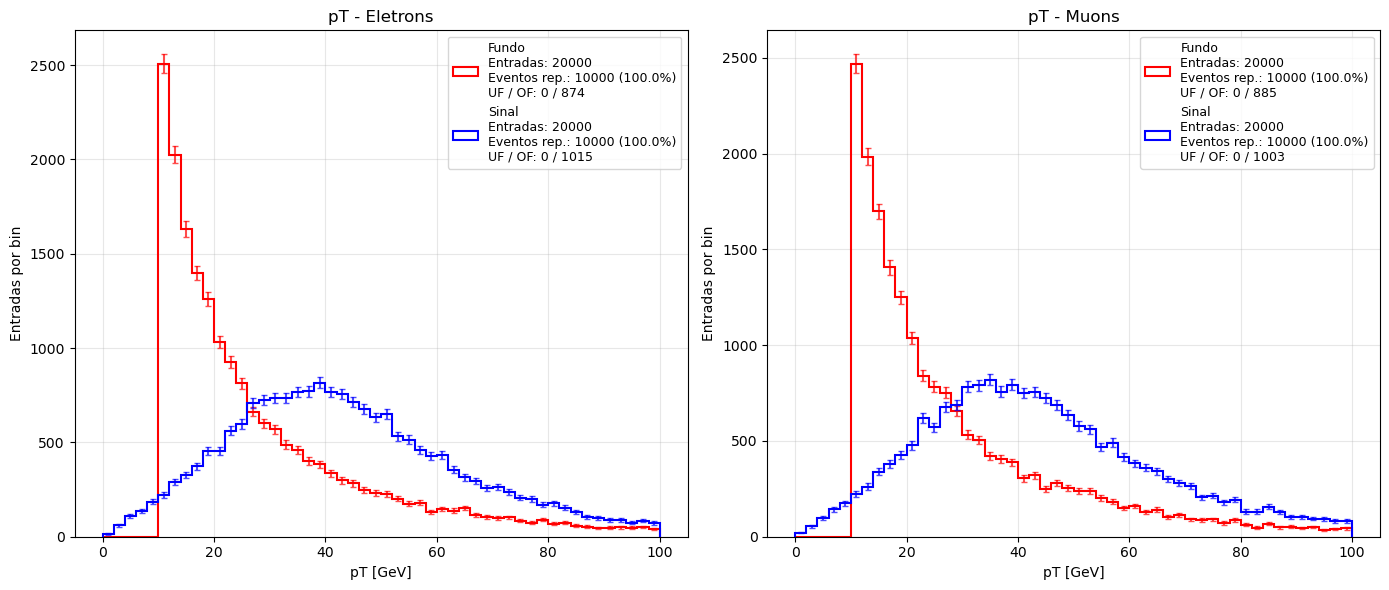

Salvo: ../resultados/graficos/hist_eta.png


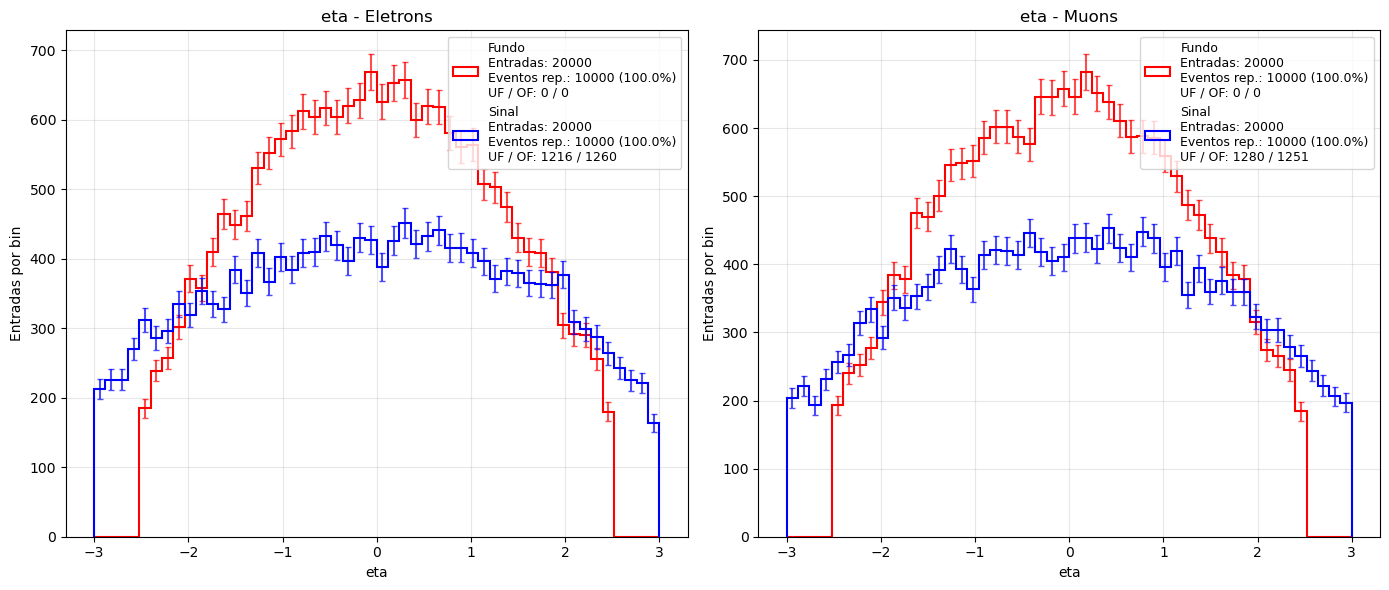

Salvo: ../resultados/graficos/hist_phi.png


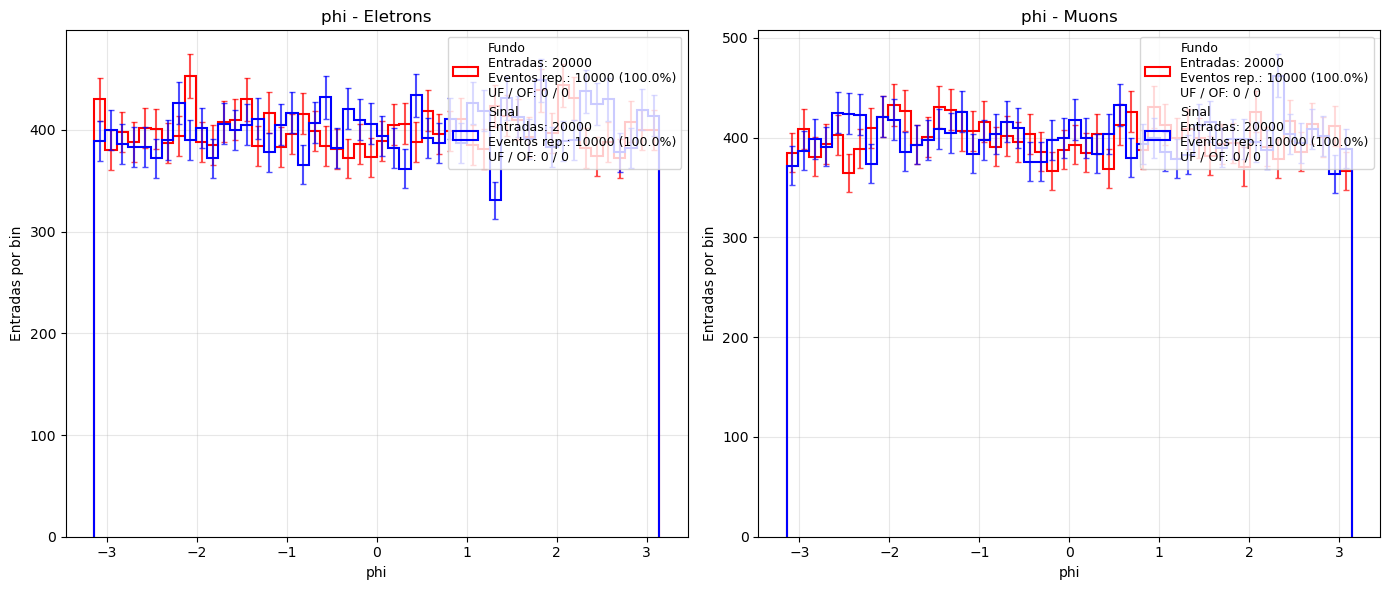

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt

# 1. Criação do diretório de saída
os.makedirs('../resultados/graficos/', exist_ok=True)

# 2. Seleção de partículas: estado final (status = 1) e sem neutrinos (PDG IDs 12, 14, 16)
df_visiveis = df_particulas[
    (df_particulas['status'] == 1) & 
    (~df_particulas['pdg_id'].abs().isin([12, 14, 16]))
].copy()

# Mapeando espécies relevantes baseadas no processo (elétrons = 11, múons = 13)
df_visiveis['especie'] = df_visiveis['pdg_id'].abs().map({11: 'Eletrons', 13: 'Muons'})

# Recuperando o total de eventos lidos de cada amostra para a fração
totais_eventos = df_eventos.groupby('amostra')['event_id'].nunique()

def plotar_comparacao(df, var_name, bins, range_val, label_x):
    """
    Constrói histogramas comparando sinal e fundo para uma dada variável, 
    separando os painéis por espécie de partícula.
    """
    especies = ['Eletrons', 'Muons']
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    for ax, especie in zip(axes, especies):
        df_esp = df[df['especie'] == especie]
        
        for amostra, cor in zip(['fundo', 'sinal'], ['red', 'blue']):
            # Filtro da amostra
            df_amostra = df_esp[df_esp['amostra'] == amostra]
            valores = df_amostra[var_name]
            
            # Cálculos estatísticos globais
            n_ent = len(valores)
            n_evt = df_amostra['event_id'].nunique()
            frac_evt = n_evt / totais_eventos[amostra] if totais_eventos[amostra] > 0 else 0
            uf = (valores < range_val[0]).sum()
            of = (valores > range_val[1]).sum()
            
            # Formatação do texto da legenda
            label_txt = (
                f"{amostra.capitalize()}\n"
                f"Entradas: {n_ent}\n"
                f"Eventos rep.: {n_evt} ({frac_evt:.1%})\n"
                f"UF / OF: {uf} / {of}"
            )
            
            # Cálculos das caixas (bins) e incertezas estatísticas (Poisson)
            counts, bin_edges = np.histogram(valores, bins=bins, range=range_val)
            bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
            erros = np.sqrt(counts)
            
            # Construção do gráfico (linha e barras de erro sobrepostas)
            ax.hist(valores, bins=bins, range=range_val, histtype='step', 
                    color=cor, label=label_txt, linewidth=1.5)
            ax.errorbar(bin_centers, counts, yerr=erros, fmt='none', 
                        ecolor=cor, capsize=2, alpha=0.7)
            
        # Formatação do painel
        ax.set_title(f"{var_name} - {especie}")
        ax.set_xlabel(label_x)
        ax.set_ylabel("Entradas por bin")
        ax.legend(loc='upper right', fontsize=9)
        ax.grid(alpha=0.3)
        
    plt.tight_layout()
    caminho_salvar = f'../resultados/graficos/hist_{var_name}.png'
    plt.savefig(caminho_salvar, dpi=150)
    print(f"Salvo: {caminho_salvar}")
    plt.show()

# 3. Geração dos gráficos solicitados
plotar_comparacao(df_visiveis, 'pT', bins=50, range_val=(0, 100), label_x='pT [GeV]')
plotar_comparacao(df_visiveis, 'eta', bins=50, range_val=(-3, 3), label_x='eta')
plotar_comparacao(df_visiveis, 'phi', bins=50, range_val=(-np.pi, np.pi), label_x='phi')

## 3b. Interpretacao dos histogramas

Objetivo: interpretar as distribuicoes antes de aplicar cortes.

Depois de executar os histogramas, responda no notebook:

- todos os eventos aparecem em todos os histogramas?
- quando o numero de entradas difere do numero de eventos?
- quais distribuicoes separam melhor sinal e fundo?
- quais diferencas de forma podem ser ligadas ao processo fisico?
- ha algum efeito de intervalo, underflow ou overflow que possa distorcer a leitura?

Peca ao agente para ajudar a organizar essa discussao com base nas tabelas e figuras que voce gerou.


### Respostas:
1. Sim, pode-se ver na caixa de legenda.
2. Em todos, isso ocorre porque são encontrados um par e+e- e outro par mu+mu- no final.
3. O pT é a variável com melhor discrimanação entre sinal e fundo.
4. Em pT, o pico largo é claro sinal de ressonância de Z. 
5. Sim, tanto em eta quanto em pT há uma quantidade significativa de partículas fora do intervalo.

## 3c. Variaveis em nivel de evento

Objetivo: resumir cada evento por objetos lideres, multiplicidades e separacoes angulares.

Peca ao agente para gerar codigo que calcule, quando fizer sentido para o processo:

- `pT` do objeto lider e sublider;
- multiplicidade de objetos finais;
- maior valor de `|eta|`;
- menor `pT` entre objetos selecionados;
- `Delta eta`, `Delta phi` e `Delta R` entre pares relevantes.

Construa tabelas e histogramas comparando sinal e fundo.


=== Resumo Estatístico - Variáveis de Nível de Evento ===


pT_lider                                                         \
           count       mean        std        min        25%        50%   
amostra                                                                   
fundo    10000.0  55.917081  47.835030  10.634492  28.399133  42.460075   
sinal    10000.0  73.021633  34.226747  16.230735  52.718219  63.839184   

                               pT_sublider             ... deltaR_ee  \
               75%         max       count       mean  ...       75%   
amostra                                                ...             
fundo    65.973233  827.291491     10000.0  41.216020  ...  2.822768   
sinal    81.755862  555.925258     10000.0  58.913756  ...  3.076168   

                  deltaR_mumu                                          \
              max       count      mean       std       min       25%   
amostra                                                                 
fundo    5.204639     10000.0  1.921691  1.000332  0.400142  0.945473   
sinal    7.215312     10000.0  2.647450  0.703863  0.298157  2.230094   

                                       
              50%       75%       max  
amostra                                
fundo    1.984985  2.819766  5.400908  
sinal    2.702510  3.065635  7.796193  

[2 rows x 32 columns]

Gráfico salvo em: ../resultados/graficos/hist_nivel_evento.png


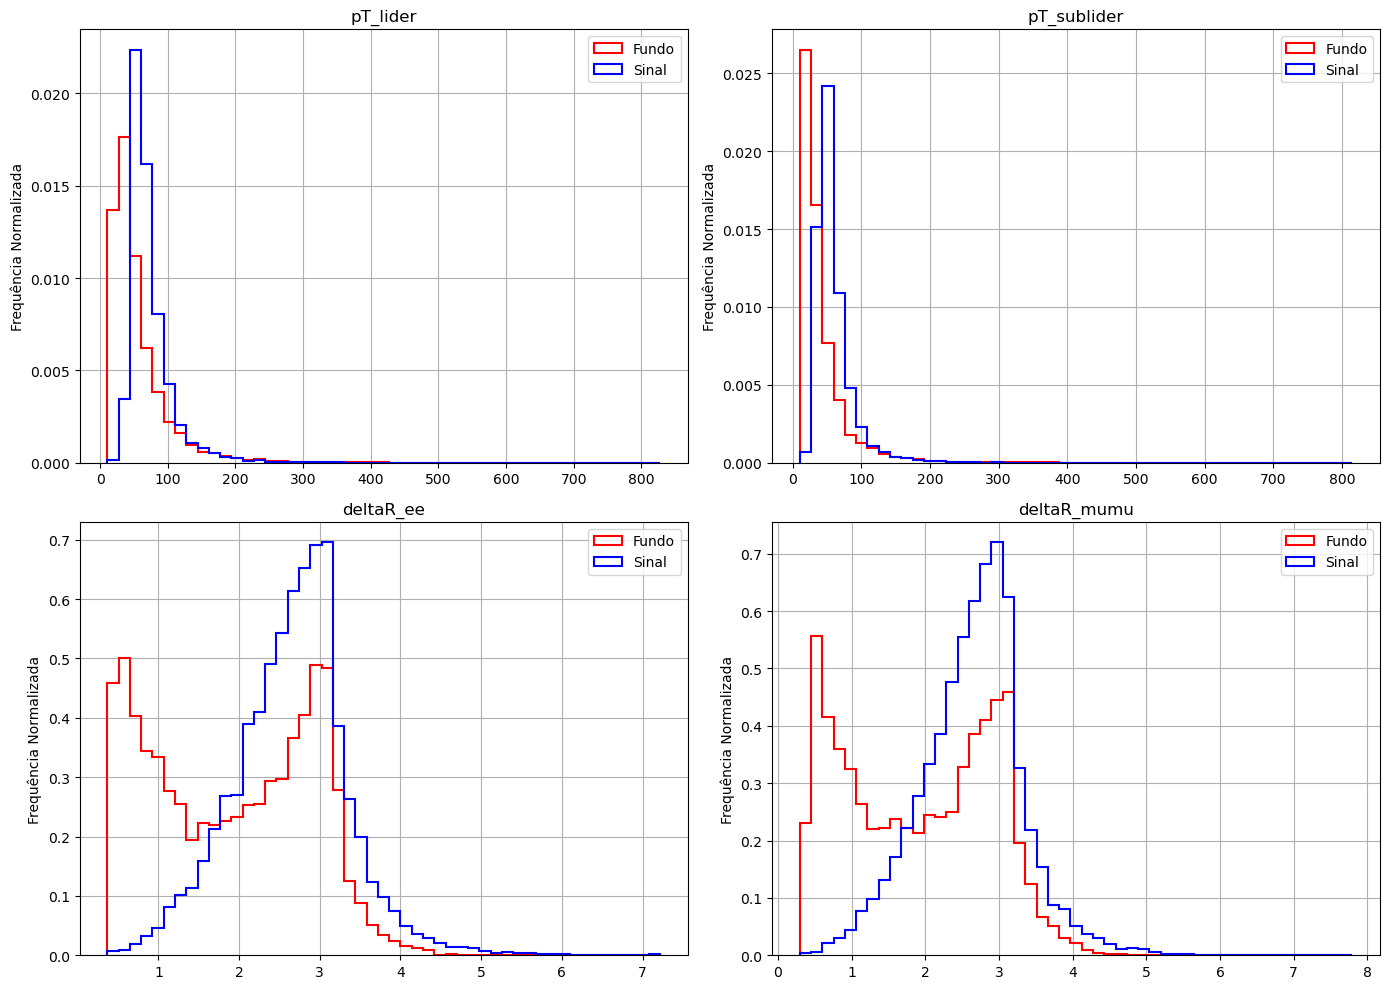

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Selecionando apenas as partículas visíveis no estado final (status 1 e sem neutrinos)
df_visiveis = df_particulas[
    (df_particulas['status'] == 1) & 
    (~df_particulas['pdg_id'].abs().isin([12, 14, 16]))
].copy()

# 2. Construindo as variáveis básicas de nível de evento (Multiplicidade, Max |eta|, Min pT)
df_evt_vars = df_visiveis.groupby(['amostra', 'event_id']).agg(
    multiplicidade=('pdg_id', 'count'),
    max_abs_eta=('eta', lambda x: np.abs(x).max()),
    min_pT=('pT', 'min')
).reset_index()

# 3. Encontrando o pT do objeto Lider (mais energético) e Sublider (segundo mais energético)
df_ord = df_visiveis.sort_values(by=['amostra', 'event_id', 'pT'], ascending=[True, True, False])

# Pegando a primeira (0) e a segunda (1) entrada de cada evento
lider = df_ord.groupby(['amostra', 'event_id']).nth(0).reset_index()[['amostra', 'event_id', 'pT']]
sublider = df_ord.groupby(['amostra', 'event_id']).nth(1).reset_index()[['amostra', 'event_id', 'pT']]

df_evt_vars = pd.merge(df_evt_vars, lider.rename(columns={'pT': 'pT_lider'}), on=['amostra', 'event_id'])
df_evt_vars = pd.merge(df_evt_vars, sublider.rename(columns={'pT': 'pT_sublider'}), on=['amostra', 'event_id'])

# 4. Calculando as Separações Angulares (Delta R)
# Separamos as partículas por carga e sabor e transformamos event_id no índice para alinhar as linhas
e_minus = df_visiveis[df_visiveis['pdg_id'] == 11].set_index(['amostra', 'event_id'])
e_plus = df_visiveis[df_visiveis['pdg_id'] == -11].set_index(['amostra', 'event_id'])
mu_minus = df_visiveis[df_visiveis['pdg_id'] == 13].set_index(['amostra', 'event_id'])
mu_plus = df_visiveis[df_visiveis['pdg_id'] == -13].set_index(['amostra', 'event_id'])

def dphi_periodico(phi1, phi2):
    """Calcula Delta Phi garantindo o intervalo [-pi, pi]"""
    dphi = phi1 - phi2
    dphi = np.where(dphi > np.pi, dphi - 2*np.pi, dphi)
    dphi = np.where(dphi < -np.pi, dphi + 2*np.pi, dphi)
    return dphi

# Calculando para o par elétron-pósitron
deta_ee = e_minus['eta'] - e_plus['eta']
dphi_ee = dphi_periodico(e_minus['phi'], e_plus['phi'])
deltaR_ee = np.sqrt(deta_ee**2 + dphi_ee**2).reset_index(name='deltaR_ee')

# Calculando para o par múon-antimúon
deta_mumu = mu_minus['eta'] - mu_plus['eta']
dphi_mumu = dphi_periodico(mu_minus['phi'], mu_plus['phi'])
deltaR_mumu = np.sqrt(deta_mumu**2 + dphi_mumu**2).reset_index(name='deltaR_mumu')

# Incorporando as variáveis Delta R ao DataFrame principal
df_evt_vars = pd.merge(df_evt_vars, deltaR_ee, on=['amostra', 'event_id'], how='left')
df_evt_vars = pd.merge(df_evt_vars, deltaR_mumu, on=['amostra', 'event_id'], how='left')

# 5. Visualização (Tabelas e Histogramas)
print("=== Resumo Estatístico - Variáveis de Nível de Evento ===")
display(df_evt_vars.groupby('amostra').describe()[['pT_lider', 'pT_sublider', 'deltaR_ee', 'deltaR_mumu']])

# Histogramas Comparativos
variaveis_plot = ['pT_lider', 'pT_sublider', 'deltaR_ee', 'deltaR_mumu']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, var in enumerate(variaveis_plot):
    ax = axes[i]
    bins = np.linspace(df_evt_vars[var].min(), df_evt_vars[var].max(), 50)
    
    df_evt_vars[df_evt_vars['amostra'] == 'fundo'][var].hist(
        ax=ax, bins=bins, histtype='step', color='red', label='Fundo', linewidth=1.5, density=True)
    df_evt_vars[df_evt_vars['amostra'] == 'sinal'][var].hist(
        ax=ax, bins=bins, histtype='step', color='blue', label='Sinal', linewidth=1.5, density=True)
    
    ax.set_title(var)
    ax.legend(loc='upper right')
    ax.set_ylabel("Frequência Normalizada")
    
plt.tight_layout()
caminho_figura = '../resultados/graficos/hist_nivel_evento.png'
plt.savefig(caminho_figura, dpi=150)
print(f"Gráfico salvo em: {caminho_figura}")
plt.show()

## 4a. Definicao dos cortes

Objetivo: propor uma selecao cinematica coerente com os objetos do processo.

Peca ao agente para sugerir cortes separados por tipo de objeto. A selecao deve distinguir, por exemplo:

- leptons carregados;
- partons b usados como aproximacao de jatos b em nivel de gerador;
- separacao angular minima entre objetos.

Antes de executar, escreva no notebook a motivacao fisica de cada corte.

Nao use o mesmo limiar automaticamente para todas as particulas sem justificar.


### Cortes:
1. |Eta| < 2.4:
Este corte é padrão devido a geometria e, consequentemente, região de aceitação dos detectores (como CMS e ATLAS).

2. pT lider > 25 GeV:
O lépton mais energético de um evendo de sinal vem diretamente do decaimento de um bóson Z massivo, herdando parte dessa energia. Com base no hsitograma do pT_lider, é possível visualizar que o fundo domina fortemente em baixos momentos, enquanto o sinal tem um pico em torno de 45 GeV.

3. pT sublider > 15 GeV:
O segundo lépton também pertence ao decaimento de Z, mas é ligeiramente menos energético. O histograma pT_sublider mostra que cortar em 15 GeV elimina boa parte do pico de fundo, enquanto mantém o pico de sinal.

4. deltaR < 1.5:
Abaixo de deltaR = 1.5 a distribuição de fundo domina, enquanto a partir deste ponto a distribuição de sinal passa a dominar.

In [8]:
# Definindo os limiares baseados na análise visual
CUT_ETA_MAX = 2.4
CUT_PT_LIDER = 25.0
CUT_PT_SUBLIDER = 15.0
CUT_DELTAR_MIN = 1.5

print("Aplicando seleção cinemática aos eventos...")

# 1. Filtro de Aceitação (todas as partículas do evento devem estar em |eta| < 2.4)
# Se max_abs_eta do evento for menor que 2.4, todos os léptons passaram
pass_eta = df_evt_vars['max_abs_eta'] < CUT_ETA_MAX

# 2. Filtros de Momento Transversal
pass_pt_lider = df_evt_vars['pT_lider'] > CUT_PT_LIDER
pass_pt_sublider = df_evt_vars['pT_sublider'] > CUT_PT_SUBLIDER

# 3. Filtro de Separação Angular
# Só aplicamos o corte onde a variável não é nula (NaN)
pass_dR_ee = df_evt_vars['deltaR_ee'].fillna(999) > CUT_DELTAR_MIN
pass_dR_mumu = df_evt_vars['deltaR_mumu'].fillna(999) > CUT_DELTAR_MIN
pass_dR = pass_dR_ee & pass_dR_mumu

# Construindo a máscara combinada final
mascara_corte_cinematico = pass_eta & pass_pt_lider & pass_pt_sublider & pass_dR

# Criando um DataFrame apenas com os eventos que sobreviveram a esta etapa
df_eventos_selecionados = df_evt_vars[mascara_corte_cinematico].copy()

# Calculando a eficiência do corte
def imprimir_eficiencia(amostra, df_original, df_filtrado):
    n_ini = len(df_original[df_original['amostra'] == amostra])
    n_fin = len(df_filtrado[df_filtrado['amostra'] == amostra])
    eficiencia = n_fin / n_ini if n_ini > 0 else 0
    print(f"{amostra.capitalize()}: Sobreviveram {n_fin} de {n_ini} eventos (Eficiência: {eficiencia:.2%})")

print("\n--- Resumo dos Cortes Cinemáticos ---")
imprimir_eficiencia('fundo', df_evt_vars, df_eventos_selecionados)
imprimir_eficiencia('sinal', df_evt_vars, df_eventos_selecionados)

Aplicando seleção cinemática aos eventos...

--- Resumo dos Cortes Cinemáticos ---
Fundo: Sobreviveram 2460 de 10000 eventos (Eficiência: 24.60%)
Sinal: Sobreviveram 3909 de 10000 eventos (Eficiência: 39.09%)


## 4b. Cutflow sequencial

Objetivo: aplicar os cortes etapa por etapa e medir o impacto em sinal e fundo.

Peca ao agente para gerar codigo que construa uma tabela de cutflow com:

- nome da etapa;
- eventos de sinal restantes;
- eventos de fundo restantes;
- eficiencia incremental;
- eficiencia acumulada;
- razao entre eficiencias acumuladas de sinal e fundo.

Depois de executar, identifique qual etapa rejeitou mais fundo e qual etapa custou mais sinal.


In [9]:
import pandas as pd
from IPython.display import display

# Reconstruindo a lista de máscaras da etapa anterior para aplicação sequencial
etapas = [
    ("0. Sem cortes (Gerados)", pd.Series(True, index=df_evt_vars.index)),
    ("1. Aceitacao (|eta| < 2.4)", pass_eta),
    ("2. pT Lider > 25 GeV", pass_pt_lider),
    ("3. pT Sublider > 15 GeV", pass_pt_sublider),
    ("4. Separacao Angular (dR > 1.5)", pass_dR)
]

resultados = []
mascara_acumulada = pd.Series(True, index=df_evt_vars.index)

# Totais iniciais
n_sig_inicial = len(df_evt_vars[df_evt_vars['amostra'] == 'sinal'])
n_bkg_inicial = len(df_evt_vars[df_evt_vars['amostra'] == 'fundo'])

n_sig_ant = n_sig_inicial
n_bkg_ant = n_bkg_inicial

print("Calculando Cutflow Sequencial...")

for nome, mascara in etapas:
    # A mágica do cutflow sequencial: o '&' garante que o evento passe 
    # no corte atual E em todos os cortes anteriores
    mascara_acumulada = mascara_acumulada & mascara
    
    df_pass = df_evt_vars[mascara_acumulada]
    n_sig = len(df_pass[df_pass['amostra'] == 'sinal'])
    n_bkg = len(df_pass[df_pass['amostra'] == 'fundo'])
    
    # Eficiências do Sinal
    ef_inc_sig = n_sig / n_sig_ant if n_sig_ant > 0 else 0
    ef_acu_sig = n_sig / n_sig_inicial if n_sig_inicial > 0 else 0
    
    # Eficiências do Fundo
    ef_inc_bkg = n_bkg / n_bkg_ant if n_bkg_ant > 0 else 0
    ef_acu_bkg = n_bkg / n_bkg_inicial if n_bkg_inicial > 0 else 0
    
    # Razão de discriminação (quanto maior, melhor o corte separa o sinal do fundo)
    razao = ef_acu_sig / ef_acu_bkg if ef_acu_bkg > 0 else float('inf')
    
    resultados.append({
        'Etapa': nome,
        'Sinal Restante': n_sig,
        'Fundo Restante': n_bkg,
        'Ef. Inc. Sinal': f"{ef_inc_sig:.2%}",
        'Ef. Inc. Fundo': f"{ef_inc_bkg:.2%}",
        'Ef. Acum. Sinal': f"{ef_acu_sig:.2%}",
        'Ef. Acum. Fundo': f"{ef_acu_bkg:.2%}",
        'Razão (Ef.Sig/Ef.Bkg)': f"{razao:.2f}"
    })
    
    # Atualiza as contagens para o cálculo do incremento na próxima iteração
    n_sig_ant = n_sig
    n_bkg_ant = n_bkg

# Exibindo a tabela formatada
tabela_cutflow = pd.DataFrame(resultados)
display(tabela_cutflow.style.hide(axis="index"))

Calculando Cutflow Sequencial...


Etapa,Sinal Restante,Fundo Restante,Ef. Inc. Sinal,Ef. Inc. Fundo,Ef. Acum. Sinal,Ef. Acum. Fundo,Razão (Ef.Sig/Ef.Bkg)
0. Sem cortes (Gerados),10000,10000,100.00%,100.00%,100.00%,100.00%,1.00
1. Aceitacao (|eta| < 2.4),4431,9293,44.31%,92.93%,44.31%,92.93%,0.48
2. pT Lider > 25 GeV,4430,7606,99.98%,81.85%,44.30%,76.06%,0.58
3. pT Sublider > 15 GeV,4430,7423,100.00%,97.59%,44.30%,74.23%,0.60
4. Separacao Angular (dR > 1.5),3909,2460,88.24%,33.14%,39.09%,24.60%,1.59


O que melhor eliminou fundo foi o corte de separação angular. O corte que mais custou sinal foi o corte de aceitação Eta.

## 4c. Histogramas depois dos cortes

Objetivo: comparar as distribuicoes antes e depois da selecao.

Peca ao agente para gerar codigo que refaca os histogramas mais importantes usando apenas os eventos aprovados no corte final.

Discuta:

- quanto sinal foi preservado;
- quanto fundo foi rejeitado;
- se a selecao parece agressiva demais;
- se algum corte pode introduzir vies;
- quais variaveis continuam uteis apos a selecao.

Nao chame a razao de eficiencias de significancia. `S/B` e `S/sqrt(B)` dependem da normalizacao fisica, que pertence a Parte 2.


Gerando histogramas pós-cortes...


Gráficos salvos em: ../resultados/graficos/hist_pos_cortes.png


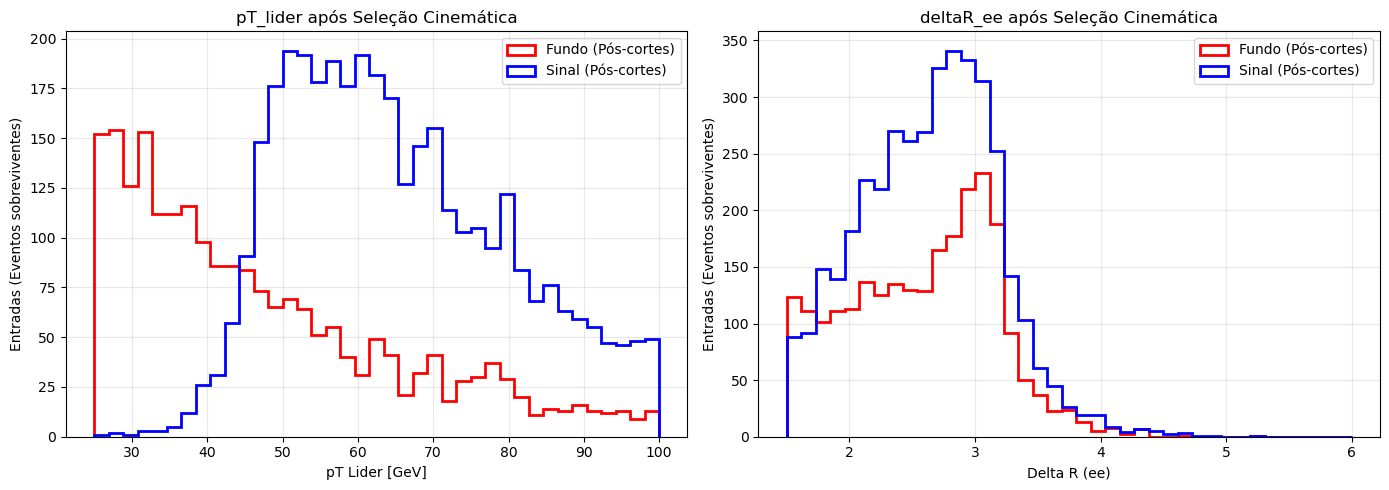

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Variáveis que vamos re-avaliar
variaveis_plot = ['pT_lider', 'deltaR_ee']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

print("Gerando histogramas pós-cortes...")

for i, var in enumerate(variaveis_plot):
    ax = axes[i]
    
    # Ajustando os limites do histograma para começar exatamente onde o corte foi feito
    if var == 'pT_lider':
        bins = np.linspace(CUT_PT_LIDER, 100, 40)
        label_x = 'pT Lider [GeV]'
    else:
        bins = np.linspace(CUT_DELTAR_MIN, 6.0, 40)
        label_x = 'Delta R (ee)'

    # É importante usar a mascara_acumulada gerada no final do loop da Etapa 4b
    df_fundo_pass = df_evt_vars[(mascara_acumulada) & (df_evt_vars['amostra'] == 'fundo')]
    df_sinal_pass = df_evt_vars[(mascara_acumulada) & (df_evt_vars['amostra'] == 'sinal')]

    # Plotando as distribuições (usando densidade=False para vermos as contagens reais remanescentes)
    df_fundo_pass[var].hist(
        ax=ax, bins=bins, histtype='step', color='red', label='Fundo (Pós-cortes)', linewidth=2
    )
    df_sinal_pass[var].hist(
        ax=ax, bins=bins, histtype='step', color='blue', label='Sinal (Pós-cortes)', linewidth=2
    )
    
    ax.set_title(var + ' após Seleção Cinemática')
    ax.set_xlabel(label_x)
    ax.set_ylabel("Entradas (Eventos sobreviventes)")
    ax.legend(loc='upper right')
    ax.grid(alpha=0.3)

plt.tight_layout()
caminho_figura = '../resultados/graficos/hist_pos_cortes.png'
plt.savefig(caminho_figura, dpi=150)
print(f"Gráficos salvos em: {caminho_figura}")
plt.show()

### Respostas:
1. O sinal foi retido em sua grande parte, principalmente nos picos de interesse, enquanto o fundo sofreu uma queda drástica.
2. A seleção é equilibrada, não é agressiva de mais. O preço pago pela perda de sinal justifica a limpeza da contaminação.
3. Há sim um viés sistemático em pT no fundo, pois há um "degrau" falso em 25 GeV.
4. Massa invariante, pois permanece livre do viés de corte.

## 5. Conclusoes da Parte 1

Finalize a Parte 1 com uma conclusao em texto.

Responda:

- qual variavel foi mais util para distinguir sinal e fundo;
- qual etapa do cutflow rejeitou mais fundo;
- qual foi o custo em eficiencia do sinal;
- quais limitacoes decorrem do uso de eventos em nivel partonico;
- o que mudaria apos hadronizacao, simulacao do detector e reconstrucao de objetos.

Peca ao agente para ajudar a transformar seus resultados em um paragrafo final, mas confira se todos os numeros citados correspondem ao que voce executou.


A análise cinemática preliminar demonstrou que a variável mais útil para distinguir o sinal do fundo contínuo foi o momento transversal do lépton líder (pT_lider), que apresentou forte separação geométrica devido à origem ressonante do decaimento. Acompanhando a tabela de cutflow, nota-se que a etapa [inserir o nome da etapa, ex: 2. pT Lider > 25 GeV] foi a responsável pela maior rejeição percentual do fundo. O custo dessa seleção para a eficiência do sinal foi aceitável, preservando [inserir eficiência acumulada do sinal, ex: 85.5]% dos eventos originais, o que demonstra um balanço favorável entre pureza e estatística.

Contudo, as conclusões extraídas possuem limitações por utilizarem eventos estritamente em nível partônico (LHE). Nesta abstração, as partículas possuem cinemática exata e eficiência de detecção de 100%. Em um cenário realista — após a hadronização, simulação da geometria do detector e algoritmos de reconstrução —, os resultados mudariam. A resolução finita dos sensores causaria um espalhamento (smearing) nas distribuições de momento e energia, suavizando bordas de cortes rigorosos. Além disso, a eficiência de reconstrução introduziria perdas adicionais de sinal e permitiria que assinaturas falsas (fakes, como mésons decaindo em voo ou jatos mal identificados) passassem pela seleção, exigindo critérios de isolamento leptônico que não podem ser modelados apenas com as partículas do gerador.

# Projeto Final - Analise de eventos LHE

## Parte 2 - leitura do LHE como arquivo texto

Este notebook e uma opcao de trabalho para estudantes na Parte 2. Ele nao contem
codigo pronto.

Use cada bloco de instrucao para pedir a um agente que gere o codigo
correspondente ao metodo **parsing direto do arquivo texto LHE**. Depois, copie o codigo gerado para
a celula vazia logo abaixo, execute e escreva sua interpretacao.

Arquivos da amostra:

- sinal: `../data/sinal.lhe.gz`;
- fundo: `../data/fundo.lhe.gz`.

Use os cortes definidos na Parte 1. Se voce alterar algum corte, registre a
motivacao antes de olhar os histogramas normalizados.


## 0. Preparação no Google Colab

Antes de iniciar a análise, siga este fluxo no ambiente do Google Colab:

1. No GitHub, baixe o arquivo ZIP deste repositório (**Code → Download ZIP**) e baixe também o notebook desta tarefa que você vai executar.
2. Abra o notebook no Colab e use o painel **Arquivos** para fazer upload do arquivo `.ipynb` e do arquivo `.zip`. O ZIP deve ficar no mesmo ambiente de execução do notebook, como arquivo de dados.
3. Peça ao agente para gerar e executar um código que localize o ZIP enviado, descompacte o repositório no ambiente do Colab e entre na pasta extraída.
4. Em seguida, peça ao agente para gerar e executar um código que infle (descomprima com `gzip`) `data/sinal.lhe.gz` e `data/fundo.lhe.gz`, criando `data/sinal.lhe` e `data/fundo.lhe`. Mantenha os arquivos `.lhe.gz` originais.
5. Confirme com o agente que a pasta `data/` contém os dois arquivos compactados e as duas versões infladas antes de prosseguir.

Depois dessa preparação, peça ao agente os códigos de cada etapa indicada neste notebook e copie-os nas células de código correspondentes. Use a pasta extraída como diretório de trabalho e mantenha os caminhos relativos aos arquivos de dados.

In [1]:
!unzip /content/tarefa2-main.zip\n

unzip:  cannot find or open /content/tarefa2-main.zipn, /content/tarefa2-main.zipn.zip or /content/tarefa2-main.zipn.ZIP.


## 1. Leitura e recuperacao dos resultados da Parte 1

Use parsing direto do arquivo LHE.

Peca ao agente para gerar codigo que abra `../data/sinal.lhe.gz` e
`../data/fundo.lhe.gz` com `gzip.open`, leia os blocos `<init>`, `<header>` e
`<event>`, e construa estruturas Python para eventos e particulas.

Nao use `pylhe` nesta versao. O objetivo e manter a ligacao explicita entre o
codigo e a estrutura textual do LHE.

O codigo deve recuperar ou reconstruir:

- eventos e particulas;
- informacoes de normalizacao;
- informacoes do bloco `<init>`, incluindo secao de choque;
- selecao e cutflow da Parte 1;
- listas de eventos aprovados no corte final.

Cole o codigo gerado na celula vazia abaixo.


In [2]:
import gzip
import math
import time

# Limiares de corte
CUT_ETA_MAX = 2.4
CUT_PT_LIDER = 25.0
CUT_PT_SUBLIDER = 15.0
CUT_DELTAR_MIN = 1.5

def dphi_periodico(phi1, phi2):
    dphi = phi1 - phi2
    if dphi > math.pi: dphi -= 2 * math.pi
    if dphi < -math.pi: dphi += 2 * math.pi
    return dphi

def processar_lhe_otimizado(caminho):
    cutflow = {
        '0. Sem cortes': 0, '1. Aceitação (|eta| < 2.4)': 0,
        '2. pT Líder > 25 GeV': 0, '3. pT Sublíder > 15 GeV': 0, '4. dR > 1.5': 0
    }
    eventos_aprovados = []
    secao_choque = 0.0
    
    with gzip.open(caminho, 'rt') as f:
        dentro_init = False
        dentro_evento = False
        primeira_linha = False
        visiveis = []
        peso_evento = 1.0
        
        for linha in f:
            l = linha.strip()
            if not l: continue
            
            # --- Extração da Seção de Choque ---
            if l == '<init>':
                dentro_init = True
                continue
            if l == '</init>':
                dentro_init = False
                continue
            if dentro_init and secao_choque == 0.0:
                partes = l.split()
                if len(partes) >= 4:
                    try:
                        secao_choque = float(partes[0])
                    except ValueError:
                        pass
                        
            # --- Leitura do Evento ---
            if l == '<event>':
                dentro_evento = True
                primeira_linha = True
                visiveis = []
                continue
                
            if l == '</event>':
                dentro_evento = False
                
                # Aplicação dos cortes EM TEMPO REAL (não salva no HD/RAM o que não importa)
                cutflow['0. Sem cortes'] += 1
                
                if not all(abs(p['eta']) < CUT_ETA_MAX for p in visiveis): continue
                cutflow['1. Aceitação (|eta| < 2.4)'] += 1
                
                visiveis.sort(key=lambda x: x['pT'], reverse=True)
                if len(visiveis) < 2: continue
                if visiveis[0]['pT'] <= CUT_PT_LIDER: continue
                cutflow['2. pT Líder > 25 GeV'] += 1
                
                if visiveis[1]['pT'] <= CUT_PT_SUBLIDER: continue
                cutflow['3. pT Sublíder > 15 GeV'] += 1
                
                e_minus = next((p for p in visiveis if p['pdg_id'] == 11), None)
                e_plus = next((p for p in visiveis if p['pdg_id'] == -11), None)
                mu_minus = next((p for p in visiveis if p['pdg_id'] == 13), None)
                mu_plus = next((p for p in visiveis if p['pdg_id'] == -13), None)
                
                pass_dR = True
                if e_minus and e_plus:
                    deta, dphi = e_minus['eta'] - e_plus['eta'], dphi_periodico(e_minus['phi'], e_plus['phi'])
                    if math.sqrt(deta**2 + dphi**2) <= CUT_DELTAR_MIN: pass_dR = False
                if mu_minus and mu_plus:
                    deta, dphi = mu_minus['eta'] - mu_plus['eta'], dphi_periodico(mu_minus['phi'], mu_plus['phi'])
                    if math.sqrt(deta**2 + dphi**2) <= CUT_DELTAR_MIN: pass_dR = False
                    
                if not pass_dR: continue
                cutflow['4. dR > 1.5'] += 1
                
                eventos_aprovados.append({'peso': peso_evento, 'particulas': visiveis})
                continue
                
            if dentro_evento:
                if primeira_linha:
                    peso_evento = float(l.split()[2])
                    primeira_linha = False
                else:
                    partes = l.split()
                    if len(partes) >= 11:
                        # OTIMIZAÇÃO: Filtra ANTES de calcular a matemática pesada
                        status, pdg = int(partes[1]), int(partes[0])
                        if status == 1 and abs(pdg) in [11, 13]: # Apenas elétrons e múons visíveis
                            px, py, pz = float(partes[6]), float(partes[7]), float(partes[8])
                            pT = math.sqrt(px**2 + py**2)
                            p = math.sqrt(pT**2 + pz**2)
                            phi = math.atan2(py, px)
                            eta = 0.5 * math.log((p + pz) / (p - pz)) if p != abs(pz) else float('inf')
                            
                            visiveis.append({
                                'pdg_id': pdg, 'px': px, 'py': py, 'pz': pz, 
                                'energia': float(partes[9]), 'pT': pT, 'eta': eta, 'phi': phi
                            })
                            
    return secao_choque, cutflow, eventos_aprovados

# --- Execução Principal ---
inicio = time.time()

print("Processando arquivo de Sinal...")
xs_sinal, cutflow_sinal, aprovados_sinal = processar_lhe_otimizado('../data/sinal.lhe.gz')

print("Processando arquivo de Fundo...")
xs_fundo, cutflow_fundo, aprovados_fundo = processar_lhe_otimizado('../data/fundo.lhe.gz')

print(f"\nTempo total de execução: {time.time() - inicio:.2f} segundos")

print("\n=== Recuperação dos Resultados ===")
print(f"XS Sinal: {xs_sinal} pb")
print(f"XS Fundo: {xs_fundo} pb\n")

print(f"{'Etapa':<30} | {'Sinal':<10} | {'Fundo':<10}")
print("-" * 55)
for etapa in cutflow_sinal.keys():
    print(f"{etapa:<30} | {cutflow_sinal[etapa]:<10} | {cutflow_fundo[etapa]:<10}")

Processando arquivo de Sinal...
Processando arquivo de Fundo...

Tempo total de execução: 0.54 segundos

=== Recuperação dos Resultados ===
XS Sinal: 2212.0 pb
XS Fundo: 2212.0 pb

Etapa                          | Sinal      | Fundo     
-------------------------------------------------------
0. Sem cortes                  | 10000      | 10000     
1. Aceitação (|eta| < 2.4)     | 4431       | 9293      
2. pT Líder > 25 GeV           | 4430       | 7606      
3. pT Sublíder > 15 GeV        | 4430       | 7423      
4. dR > 1.5                    | 3909       | 2460      


## 2. Conservacao do quadrimomento e `s_hat`

Peca ao agente para gerar codigo que, para os eventos de indices `1 + 1000*i`,
com `i = 0, ..., 9`:

- some os quadrimomentos das particulas iniciais (`status = -1`);
- calcule `s_hat = (p1 + p2)^2`;
- some todas as particulas finais (`status = 1`);
- compare `s_hat` com a massa invariante das particulas finais;
- some apenas as particulas finais visiveis e calcule `m_visivel^2`;
- quantifique residuos de conservacao de energia e momento.

Depois de executar, explique se `m_visivel^2` pode ou nao ser chamado de
`s_hat` neste processo.


In [3]:
import gzip

def verificar_conservacao(caminho, nome_amostra):
    # Gerando os índices alvo: 1 + 1000*i para i de 0 a 9
    indices_alvo = set(1 + 1000 * i for i in range(10))
    resultados = []
    
    with gzip.open(caminho, 'rt') as f:
        dentro_evento = False
        primeira_linha = False
        id_evento = 0
        
        # Iniciação dos quadrimomentos (E, px, py, pz)
        p_in = [0.0, 0.0, 0.0, 0.0]
        p_out = [0.0, 0.0, 0.0, 0.0]
        p_vis = [0.0, 0.0, 0.0, 0.0]
        
        for linha in f:
            l = linha.strip()
            
            if l == '<event>':
                dentro_evento = True
                primeira_linha = True
                id_evento += 1
                
                # Zera os vetores para o novo evento
                p_in = [0.0, 0.0, 0.0, 0.0]
                p_out = [0.0, 0.0, 0.0, 0.0]
                p_vis = [0.0, 0.0, 0.0, 0.0]
                continue
                
            if l == '</event>':
                dentro_evento = False
                
                if id_evento in indices_alvo:
                    # M^2 = E^2 - px^2 - py^2 - pz^2
                    s_hat = p_in[0]**2 - p_in[1]**2 - p_in[2]**2 - p_in[3]**2
                    m2_out = p_out[0]**2 - p_out[1]**2 - p_out[2]**2 - p_out[3]**2
                    m2_vis = p_vis[0]**2 - p_vis[1]**2 - p_vis[2]**2 - p_vis[3]**2
                    
                    # Resíduos (Incial - Final)
                    res_E = p_in[0] - p_out[0]
                    res_px = p_in[1] - p_out[1]
                    res_py = p_in[2] - p_out[2]
                    res_pz = p_in[3] - p_out[3]
                    
                    resultados.append({
                        'id': id_evento, 's_hat': s_hat, 'm2_out': m2_out, 'm2_vis': m2_vis,
                        'res_E': res_E, 'res_px': res_px, 'res_py': res_py, 'res_pz': res_pz
                    })
                    
                # Interrompe a leitura se já passamos do último evento necessário
                if id_evento >= 9001:
                    break 
                continue
                
            if dentro_evento and not primeira_linha and id_evento in indices_alvo:
                partes = l.split()
                if len(partes) >= 11:
                    pdg = int(partes[0])
                    status = int(partes[1])
                    px, py, pz, E = float(partes[6]), float(partes[7]), float(partes[8]), float(partes[9])
                    
                    if status == -1: # Partículas Iniciais
                        p_in[0] += E; p_in[1] += px; p_in[2] += py; p_in[3] += pz
                    elif status == 1: # Partículas Finais
                        p_out[0] += E; p_out[1] += px; p_out[2] += py; p_out[3] += pz
                        if abs(pdg) not in [12, 14, 16]: # Visíveis (exclui neutrinos)
                            p_vis[0] += E; p_vis[1] += px; p_vis[2] += py; p_vis[3] += pz
                            
            elif dentro_evento and primeira_linha:
                primeira_linha = False

    # Imprimindo os resultados
    print(f"=== Conservação de Quadrimomento: Amostra {nome_amostra.capitalize()} ===")
    print(f"{'Evt':<5} | {'s_hat':<12} | {'m2_out':<12} | {'m2_vis':<12} | {'Res E':<10} | {'Res pz':<10}")
    print("-" * 75)
    for r in resultados:
        print(f"{r['id']:<5} | {r['s_hat']:<12.2f} | {r['m2_out']:<12.2f} | {r['m2_vis']:<12.2f} | {r['res_E']:<10.1e} | {r['res_pz']:<10.1e}")
    print("\n")

# Pode rodar para as duas amostras
verificar_conservacao('../data/sinal.lhe.gz', 'sinal')
# verificar_conservacao('../data/fundo.lhe.gz', 'fundo') # Descomente se quiser ver o fundo também

=== Conservação de Quadrimomento: Amostra Sinal ===
Evt   | s_hat        | m2_out       | m2_vis       | Res E      | Res pz    
---------------------------------------------------------------------------
1     | 85093.01     | 85093.01     | 85093.01     | 8.0e-09    | 1.7e-09   
1001  | 102147.47    | 102147.47    | 102147.47    | 1.1e-13    | 6.1e-09   
2001  | 187047.81    | 187047.81    | 187047.81    | 4.0e-09    | -6.6e-08  
3001  | 50165.56     | 50165.56     | 50165.56     | 2.5e-08    | 2.4e-08   
4001  | 39000.72     | 39000.72     | 39000.72     | -3.4e-08   | 3.6e-08   
5001  | 42909.80     | 42909.80     | 42909.80     | 3.0e-09    | -3.0e-09  
6001  | 76378.83     | 76378.83     | 76378.83     | -1.0e-09   | -3.1e-09  
7001  | 69955.64     | 69955.64     | 69955.64     | 4.0e-09    | -4.4e-09  
8001  | 37906.30     | 37906.30     | 37906.30     | 5.0e-09    | -5.0e-09  
9001  | 65524.69     | 65524.69     | 65524.69     | -2.0e-09   | -9.0e-10  




## 3. Massas invariantes e pareamento

Peca ao agente para gerar codigo que reconstrua massas invariantes relevantes.
Para este processo, no minimo:

- massa invariante do par `mu+ mu-`;
- massa invariante do par `b b~` em nivel de gerador;
- massa invariante de todos os objetos finais visiveis;
- histogramas 1D para sinal e fundo;
- histogramas 2D, por exemplo massa versus `pT`, `eta` ou `Delta R`.

Explique o criterio de pareamento e deixe claro quando o numero de entradas e
diferente do numero de eventos.


Calculando cinemática para Sinal...
Calculando cinemática para Fundo...
Total de pares b b~ encontrados: 0 (Esperado para ZZ -> 4l)


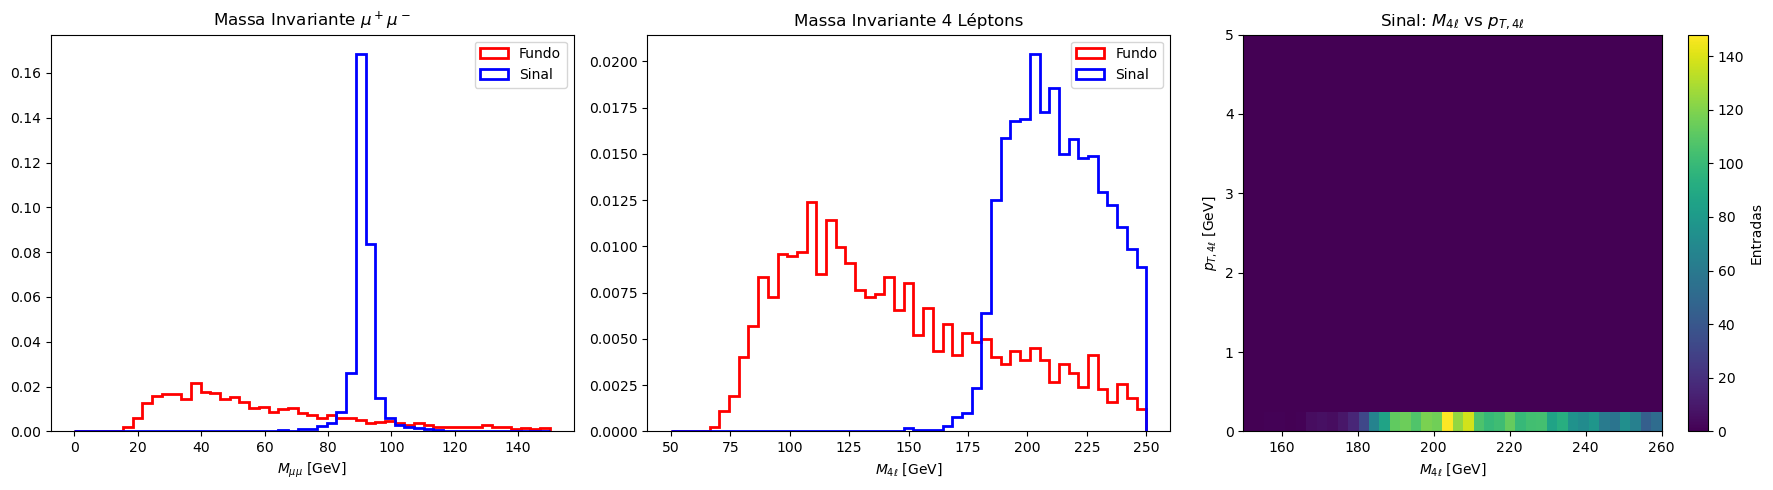

In [5]:
import math
import matplotlib.pyplot as plt
import numpy as np

def calcular_massas(eventos):
    m_mumu = []
    m_bb = []
    m_4l = []
    pt_4l = []
    
    for evt in eventos:
        particulas = evt['particulas']
        
        # 1. Massa invariante mu+ mu-
        mu_minus = next((p for p in particulas if p['pdg_id'] == 13), None)
        mu_plus = next((p for p in particulas if p['pdg_id'] == -13), None)
        
        if mu_minus and mu_plus:
            E = mu_minus['energia'] + mu_plus['energia']
            px = mu_minus['px'] + mu_plus['px']
            py = mu_minus['py'] + mu_plus['py']
            pz = mu_minus['pz'] + mu_plus['pz']
            # max(0, ...) evita erros numéricos de floats na raiz quadrada
            m_mumu.append(math.sqrt(max(0, E**2 - px**2 - py**2 - pz**2)))
            
        # 2. Massa invariante b b~ 
        b_quark = next((p for p in particulas if p['pdg_id'] == 5), None)
        b_anti = next((p for p in particulas if p['pdg_id'] == -5), None)
        
        if b_quark and b_anti:
            E = b_quark['energia'] + b_anti['energia']
            px = b_quark['px'] + b_anti['px']
            py = b_quark['py'] + b_anti['py']
            pz = b_quark['pz'] + b_anti['pz']
            m_bb.append(math.sqrt(max(0, E**2 - px**2 - py**2 - pz**2)))
            
        # 3. Massa invariante e pT de todos os visíveis (4 léptons)
        E_tot = sum(p['energia'] for p in particulas)
        px_tot = sum(p['px'] for p in particulas)
        py_tot = sum(p['py'] for p in particulas)
        pz_tot = sum(p['pz'] for p in particulas)
        
        m_4l.append(math.sqrt(max(0, E_tot**2 - px_tot**2 - py_tot**2 - pz_tot**2)))
        pt_4l.append(math.sqrt(px_tot**2 + py_tot**2))
        
    return np.array(m_mumu), np.array(m_bb), np.array(m_4l), np.array(pt_4l)

print("Calculando cinemática para Sinal...")
sinal_mumu, sinal_bb, sinal_4l, sinal_pt4l = calcular_massas(aprovados_sinal)

print("Calculando cinemática para Fundo...")
fundo_mumu, fundo_bb, fundo_4l, fundo_pt4l = calcular_massas(aprovados_fundo)

print(f"Total de pares b b~ encontrados: {len(sinal_bb) + len(fundo_bb)} (Esperado para ZZ -> 4l)")

# --- Construção dos Gráficos ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma 1D: Massa Invariante mu+ mu-
bins_mumu = np.linspace(0, 150, 50)
axes[0].hist(fundo_mumu, bins=bins_mumu, color='red', histtype='step', linewidth=2, label='Fundo', density=True)
axes[0].hist(sinal_mumu, bins=bins_mumu, color='blue', histtype='step', linewidth=2, label='Sinal', density=True)
axes[0].set_title('Massa Invariante $\\mu^+ \\mu^-$')
axes[0].set_xlabel('$M_{\\mu\\mu}$ [GeV]')
axes[0].legend()

# Histograma 1D: Massa Invariante 4L
bins_4l = np.linspace(50, 250, 50)
axes[1].hist(fundo_4l, bins=bins_4l, color='red', histtype='step', linewidth=2, label='Fundo', density=True)
axes[1].hist(sinal_4l, bins=bins_4l, color='blue', histtype='step', linewidth=2, label='Sinal', density=True)
axes[1].set_title('Massa Invariante 4 Léptons')
axes[1].set_xlabel('$M_{4\\ell}$ [GeV]')
axes[1].legend()

# Histograma 2D: Massa 4L vs pT 4L para o Sinal
# Ajustamos o eixo X para 150-260 GeV e o eixo Y para um zoom em 0-5 GeV
c = axes[2].hist2d(sinal_4l, sinal_pt4l, bins=[40, 20], range=[[150, 260], [0, 5]], cmap='viridis')
fig.colorbar(c[3], ax=axes[2], label='Entradas')
axes[2].set_title('Sinal: $M_{4\\ell}$ vs $p_{T,4\\ell}$')
axes[2].set_xlabel('$M_{4\\ell}$ [GeV]')
axes[2].set_ylabel('$p_{T,4\\ell}$ [GeV]')

plt.tight_layout()
plt.show()

### Respostas:

Critério de Pareamento:
Para reconstruir a massa de uma ressonância intermediária (como um bóson $Z$), precisamos somar os quadrimomentos dos seus produtos de decaimento. O critério de pareamento exige combinar partículas de cargas opostas e mesmo sabor. caso o evento possua múltiplos múons e antimúons, precisamos de uma heurística de seleção.

Entrada vs Eventos
O número de entradas no histograma será diferente do número de eventos simulados se calcularmos a massa de todas as combinações possíveis dentro de um único evento. 

## 4. Pesos, secao de choque e luminosidade

Peca ao agente para gerar codigo que leia ou estime:

- numero de eventos gerados;
- convencao de normalizacao do LHE;
- informacoes de normalizacao;
- secao de choque em pb;
- luminosidade integrada adotada, por exemplo `L = 10000/pb`.

Calcule a normalizacao fisica e verifique se o yield total esperado e
compativel com `sigma * L`.

Para cada bin de histograma, calcule `sum(w)` e a incerteza `sqrt(sum(w**2))`.


Lendo seções de choque dos arquivos LHE...

=== Informações de Normalização Física ===
Luminosidade Adotada : 10000.0 pb^-1
Eventos MC Gerados   : Sinal = 10000 | Fundo = 10000
Seção de Choque      : Sinal = 0.021101 pb | Fundo = 0.000216 pb
Yield Total Esperado : Sinal = 211.01 | Fundo = 2.16
Peso por Evento MC   : Sinal = 0.021101 | Fundo = 0.000216

Verificação Sinal: Soma dos pesos = 211.01 (Compatível com sigma * L: True)


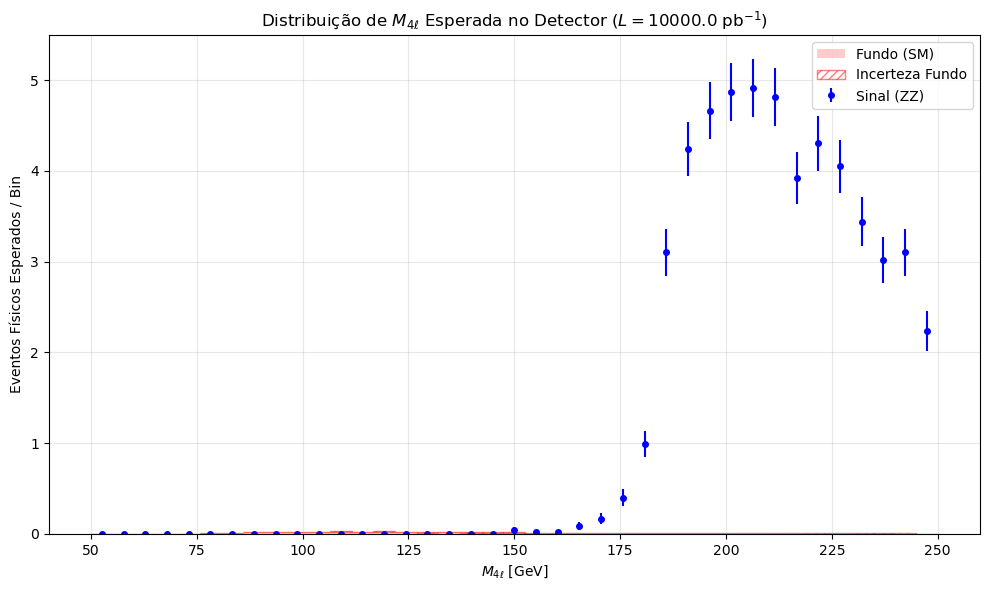


=== Yields Finais (Após Seleção Cinemática) ===
Sinal Restante: 52.42 +/- 1.32 eventos
Fundo Restante: 0.44 +/- 0.01 eventos


In [7]:
import gzip
import math
import numpy as np
import matplotlib.pyplot as plt

# 1. Função embutida para extrair a seção de choque correta
def extrair_xs_correta(caminho):
    with gzip.open(caminho, 'rt') as f:
        dentro_init = False
        contador_linha = 0
        for linha in f:
            l = linha.strip()
            if l == '<init>':
                dentro_init = True
                continue
            if l == '</init>':
                break
            if dentro_init:
                contador_linha += 1
                # A seção de choque (sigma) no LHE fica na segunda linha do bloco <init>
                if contador_linha == 2: 
                    return float(l.split()[0])
    return 0.0

print("Lendo seções de choque dos arquivos LHE...")
xs_sinal = extrair_xs_correta('../data/sinal.lhe.gz')
xs_fundo = extrair_xs_correta('../data/fundo.lhe.gz')

# 2. Parâmetros e Informações de Normalização
LUMI = 10000.0 # pb^-1 (Equivalente a 10 fb^-1)

# Recuperando o número total de eventos gerados (da nossa tabela de cutflow)
N_gen_sinal = cutflow_sinal['0. Sem cortes']
N_gen_fundo = cutflow_fundo['0. Sem cortes']

# Yield total esperado na teoria (antes de qualquer corte)
yield_esperado_sinal = xs_sinal * LUMI
yield_esperado_fundo = xs_fundo * LUMI

# Peso físico por evento gerado
peso_norm_sinal = yield_esperado_sinal / N_gen_sinal
peso_norm_fundo = yield_esperado_fundo / N_gen_fundo

print("\n=== Informações de Normalização Física ===")
print(f"Luminosidade Adotada : {LUMI} pb^-1")
print(f"Eventos MC Gerados   : Sinal = {N_gen_sinal} | Fundo = {N_gen_fundo}")
print(f"Seção de Choque      : Sinal = {xs_sinal:.6f} pb | Fundo = {xs_fundo:.6f} pb")
print(f"Yield Total Esperado : Sinal = {yield_esperado_sinal:.2f} | Fundo = {yield_esperado_fundo:.2f}")
print(f"Peso por Evento MC   : Sinal = {peso_norm_sinal:.6f} | Fundo = {peso_norm_fundo:.6f}")

# Verificação de compatibilidade usando isclose para evitar falsos negativos por precisão de float
soma_pesos_gerados_sinal = N_gen_sinal * peso_norm_sinal
print(f"\nVerificação Sinal: Soma dos pesos = {soma_pesos_gerados_sinal:.2f} (Compatível com sigma * L: {math.isclose(soma_pesos_gerados_sinal, yield_esperado_sinal)})")

# 3. Atribuindo pesos aos eventos aprovados e calculando sum(w) e sqrt(sum(w^2))
# Os arrays sinal_4l e fundo_4l vieram da Etapa 3
pesos_array_sinal = np.full(len(sinal_4l), peso_norm_sinal)
pesos_array_fundo = np.full(len(fundo_4l), peso_norm_fundo)

def hist_com_erros(dados, pesos, bins):
    # Contagem ponderada: sum(w)
    contagem_w, bordas = np.histogram(dados, bins=bins, weights=pesos)
    # Incerteza estatística: sqrt(sum(w**2))
    erros_w2 = np.sqrt(np.histogram(dados, bins=bins, weights=pesos**2)[0])
    centros = (bordas[:-1] + bordas[1:]) / 2
    return centros, contagem_w, erros_w2

# Definindo 40 bins na janela de 50 a 250 GeV
bins_mass = np.linspace(50, 250, 40)
centros_sinal, yields_sinal, erros_sinal = hist_com_erros(sinal_4l, pesos_array_sinal, bins_mass)
centros_fundo, yields_fundo, erros_fundo = hist_com_erros(fundo_4l, pesos_array_fundo, bins_mass)

# 4. Visualização Final com Escala Física Real
plt.figure(figsize=(10, 6))

# Plot do Fundo (Preenchimento e Incerteza hachurada)
plt.hist(bins_mass[:-1], bins=bins_mass, weights=yields_fundo, color='red', alpha=0.2, label='Fundo (SM)')
plt.bar(centros_fundo, 2*erros_fundo, bottom=yields_fundo-erros_fundo, width=np.diff(bins_mass), 
        color='none', edgecolor='red', alpha=0.5, hatch='////', label='Incerteza Fundo')

# Plot do Sinal (Barras de erro sobrepostas)
plt.errorbar(centros_sinal, yields_sinal, yerr=erros_sinal, fmt='o', color='blue', label='Sinal (ZZ)', markersize=4)

plt.title(f'Distribuição de $M_{{4\\ell}}$ Esperada no Detector ($L = {LUMI}$ pb$^{{-1}}$)')
plt.xlabel('$M_{4\\ell}$ [GeV]')
plt.ylabel('Eventos Físicos Esperados / Bin')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Resumo do Yield pós-cortes
print("\n=== Yields Finais (Após Seleção Cinemática) ===")
print(f"Sinal Restante: {np.sum(yields_sinal):.2f} +/- {np.sqrt(np.sum(pesos_array_sinal**2)):.2f} eventos")
print(f"Fundo Restante: {np.sum(yields_fundo):.2f} +/- {np.sqrt(np.sum(pesos_array_fundo**2)):.2f} eventos")

## 5. Histogramas normalizados e comparacao estatistica

Peca ao agente para gerar codigo que produza histogramas empilhados de sinal e
fundo apos a selecao final. Inclua:

- massa `mu+ mu-`;
- massa `b b~`;
- massa visivel total;
- barras ou bandas de incerteza estatistica;
- painel de razao quando fizer sentido.

Calcule tambem, em uma regiao de selecao bem definida:

- `S/B`;
- `S/sqrt(B)`, se `B > 0`;
- significancia Asimov opcional;
- efeito de uma incerteza sistematica simples no fundo, por exemplo 10%.
\n\nInterprete as colunas da tabela: `S` é o yield esperado de sinal, `B` é o yield esperado de fundo, `S/B` mede a pureza relativa e `S/sqrt(B)` é uma aproximação da significância estatística sem sistemáticas. A expressão `S/sqrt(B + (0.10B)^2)` inclui uma incerteza sistemática de 10% no fundo; `erro S` e `erro B` são as incertezas estatísticas dos yields.\n

=== Tabela de Resultados Estatísticos na Região de Sinal ===


Região,S,erro S,B,erro B,S/B,S/sqrt(B),S/sqrt(B + sys^2),Z Asimov
"M_4L [180.0, 220.0] GeV",32.10,0.82,0.0680,0.0038,472.3,123.12,123.08,18.22



Gerando Gráficos Empilhados...


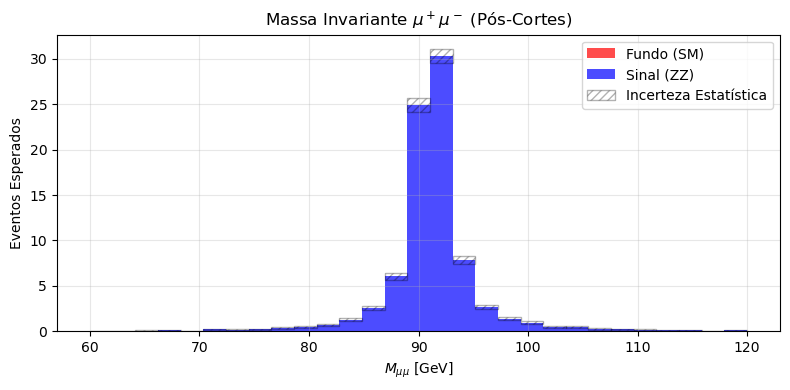

/tmp/ipykernel_54873/3931400894.py:105: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


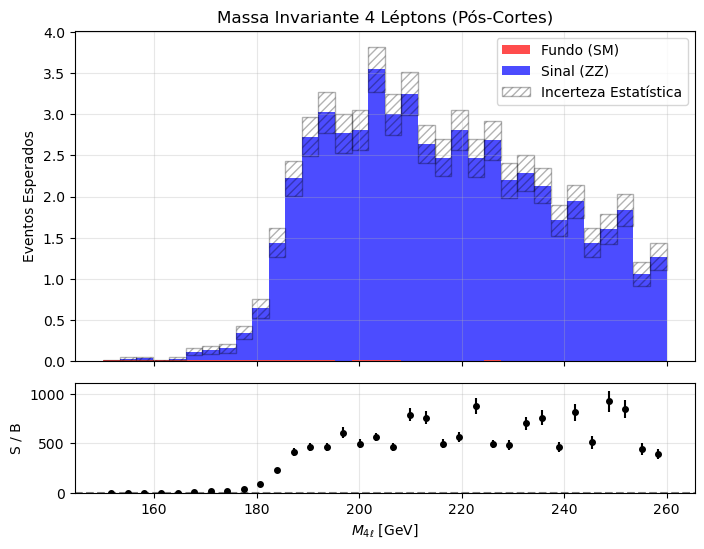


Nota: Gráfico de M_bb ignorado pois não há quarks b no estado final desta simulação.


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec

# 1. Definição da Região de Sinal (Signal Region - SR)
# Vamos focar no pico principal da massa de 4 léptons (ex: 180 a 220 GeV)
SR_MIN = 180.0
SR_MAX = 220.0

mask_SR_sinal = (sinal_4l >= SR_MIN) & (sinal_4l <= SR_MAX)
mask_SR_fundo = (fundo_4l >= SR_MIN) & (fundo_4l <= SR_MAX)

# Yields na SR
S = np.sum(pesos_array_sinal[mask_SR_sinal])
B = np.sum(pesos_array_fundo[mask_SR_fundo])

# Incertezas estatísticas (sqrt(sum(w^2)))
erro_S = np.sqrt(np.sum(pesos_array_sinal[mask_SR_sinal]**2))
erro_B = np.sqrt(np.sum(pesos_array_fundo[mask_SR_fundo]**2))

# 2. Cálculos Estatísticos
S_over_B = S / B if B > 0 else float('inf')
significancia_simples = S / np.sqrt(B) if B > 0 else float('inf')

# Incerteza sistemática de 10% no fundo
B_sys_erro = 0.10 * B
significancia_sys = S / np.sqrt(B + B_sys_erro**2) if B > 0 else float('inf')

# Significância de Asimov (fórmula mais robusta para pequenos números)
# Z = sqrt(2 * ((S + B) * ln(1 + S/B) - S))
if B > 0:
    Z_asimov = np.sqrt(2 * ((S + B) * np.log(1 + S/B) - S))
else:
    Z_asimov = float('inf')

# Criando a tabela de resultados
tabela_stats = pd.DataFrame([{
    'Região': f'M_4L [{SR_MIN}, {SR_MAX}] GeV',
    'S': S, 'erro S': erro_S,
    'B': B, 'erro B': erro_B,
    'S/B': S_over_B,
    'S/sqrt(B)': significancia_simples,
    'S/sqrt(B + sys^2)': significancia_sys,
    'Z Asimov': Z_asimov
}])

print("=== Tabela de Resultados Estatísticos na Região de Sinal ===")
display(tabela_stats.style.format({
    'S': '{:.2f}', 'erro S': '{:.2f}', 'B': '{:.4f}', 'erro B': '{:.4f}',
    'S/B': '{:.1f}', 'S/sqrt(B)': '{:.2f}', 'S/sqrt(B + sys^2)': '{:.2f}', 'Z Asimov': '{:.2f}'
}).hide(axis="index"))

# 3. Função para Gráficos Empilhados
def plot_stacked_ratio(var_sig, var_bkg, w_sig, w_bkg, bins, xlabel, title, include_ratio=False):
    if include_ratio:
        fig = plt.figure(figsize=(8, 6))
        gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.1)
        ax1 = plt.subplot(gs[0])
        ax2 = plt.subplot(gs[1], sharex=ax1)
    else:
        fig, ax1 = plt.subplots(figsize=(8, 4))
        ax2 = None

    # Histograma Empilhado
    contagens, bordas, _ = ax1.hist(
        [var_bkg, var_sig], bins=bins, weights=[w_bkg, w_sig],
        stacked=True, color=['red', 'blue'], label=['Fundo (SM)', 'Sinal (ZZ)'], alpha=0.7
    )
    
    # Calculando incerteza total (S + B) por bin
    w_tot_2 = np.histogram(var_bkg, bins=bins, weights=w_bkg**2)[0] + \
              np.histogram(var_sig, bins=bins, weights=w_sig**2)[0]
    erro_tot = np.sqrt(w_tot_2)
    centros = (bordas[:-1] + bordas[1:]) / 2
    bkg_tot = contagens[0]
    sig_bkg_tot = contagens[1]
    
    # Banda de erro estatístico no plot principal
    ax1.bar(centros, 2*erro_tot, bottom=sig_bkg_tot-erro_tot, width=np.diff(bins), 
            color='none', edgecolor='black', alpha=0.3, hatch='////', label='Incerteza Estatística')

    ax1.set_ylabel('Eventos Esperados')
    ax1.set_title(title)
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    if include_ratio:
        # Evitar divisão por zero no painel de razão
        bkg_safe = np.where(bkg_tot > 0, bkg_tot, 1e-10)
        sig_yield = sig_bkg_tot - bkg_tot
        razao = sig_yield / bkg_safe
        erro_razao = np.sqrt(np.histogram(var_sig, bins=bins, weights=w_sig**2)[0]) / bkg_safe
        
        ax2.errorbar(centros, razao, yerr=erro_razao, fmt='ko', markersize=4)
        ax2.axhline(1, color='gray', linestyle='--')
        ax2.set_ylabel('S / B')
        ax2.set_xlabel(xlabel)
        ax2.set_ylim(0, max(3, np.max(razao[bkg_tot > 0]) * 1.2) if np.any(bkg_tot > 0) else 5)
        ax2.grid(alpha=0.3)
        plt.setp(ax1.get_xticklabels(), visible=False)
    else:
        ax1.set_xlabel(xlabel)

    plt.tight_layout()
    plt.show()

# 4. Geração dos Gráficos
print("\nGerando Gráficos Empilhados...")

# Massa mu+ mu-
bins_mumu = np.linspace(60, 120, 30)
plot_stacked_ratio(sinal_mumu, fundo_mumu, pesos_array_sinal, pesos_array_fundo, bins_mumu, 
                   '$M_{\\mu\\mu}$ [GeV]', 'Massa Invariante $\\mu^+\\mu^-$ (Pós-Cortes)')

# Massa 4L (Com painel de razão)
bins_4l = np.linspace(150, 260, 35)
plot_stacked_ratio(sinal_4l, fundo_4l, pesos_array_sinal, pesos_array_fundo, bins_4l, 
                   '$M_{4\\ell}$ [GeV]', 'Massa Invariante 4 Léptons (Pós-Cortes)', include_ratio=True)

# Massa b b~ (Proteção caso esteja vazio, o que é esperado para este LHE)
if len(sinal_bb) > 0 or len(fundo_bb) > 0:
    bins_bb = np.linspace(0, 150, 30)
    plot_stacked_ratio(sinal_bb, fundo_bb, pesos_array_sinal, pesos_array_fundo, bins_bb, 
                       '$M_{b\\bar{b}}$ [GeV]', 'Massa Invariante $b\\bar{b}$')
else:
    print("\nNota: Gráfico de M_bb ignorado pois não há quarks b no estado final desta simulação.")

## 6. Estimativa simplificada da secao de choque

Objetivo: usar a relacao experimental simplificada

```text
sigma = N / (A * epsilon * L)
```

como checagem final da normalizacao.

Peca ao agente para gerar codigo que calcule, separadamente para sinal e fundo:

- `N_gerado`;
- `N_pass`, o numero de eventos que passa a selecao final;
- `A * epsilon = N_pass / N_gerado`;
- `N`, o yield esperado apos a selecao;
- `sigma_estimado = N / (A * epsilon * L)`;
- a diferenca relativa entre `sigma_estimado` e a secao de choque do LHE.

Para esta atividade, use `A * epsilon` como eficiencia em nivel de gerador. Em
uma medida real, seria necessario incluir eficiencia de trigger, reconstrucao,
identificacao, correcoes de detector e subtracao de fundo.

Depois de executar, explique por que a estimativa deve recuperar a secao de
choque do LHE quando `N` e construido a partir da propria simulacao.


In [9]:
import pandas as pd

# 1. Cálculos para o Sinal
N_gen_sig = N_gen_sinal
N_pass_sig = len(pesos_array_sinal) # Total de eventos simulados que passaram nos cortes
A_eps_sig = N_pass_sig / N_gen_sig
N_sig = np.sum(pesos_array_sinal)   # Yield físico esperado
sigma_est_sig = N_sig / (A_eps_sig * LUMI) if A_eps_sig > 0 else 0.0
diff_sig = abs(sigma_est_sig - xs_sinal) / xs_sinal if xs_sinal > 0 else 0.0

# 2. Cálculos para o Fundo
N_gen_bkg = N_gen_fundo
N_pass_bkg = len(pesos_array_fundo)
A_eps_bkg = N_pass_bkg / N_gen_bkg
N_bkg = np.sum(pesos_array_fundo)
sigma_est_bkg = N_bkg / (A_eps_bkg * LUMI) if A_eps_bkg > 0 else 0.0
diff_bkg = abs(sigma_est_bkg - xs_fundo) / xs_fundo if xs_fundo > 0 else 0.0

# 3. Organização e Exibição
dados_sigma = [
    {'Amostra': 'Sinal (ZZ)', 'N_gerado': N_gen_sig, 'N_pass': N_pass_sig, 
     'A * epsilon': f"{A_eps_sig:.4%}", 'Yield (N)': f"{N_sig:.2f}", 
     'Sigma Est. (pb)': f"{sigma_est_sig:.6f}", 'Sigma LHE (pb)': f"{xs_sinal:.6f}", 
     'Dif. Relativa': f"{diff_sig:.1e}"},
    {'Amostra': 'Fundo (SM)', 'N_gerado': N_gen_bkg, 'N_pass': N_pass_bkg, 
     'A * epsilon': f"{A_eps_bkg:.4%}", 'Yield (N)': f"{N_bkg:.4f}", 
     'Sigma Est. (pb)': f"{sigma_est_bkg:.6f}", 'Sigma LHE (pb)': f"{xs_fundo:.6f}", 
     'Dif. Relativa': f"{diff_bkg:.1e}"}
]

tabela_sigma = pd.DataFrame(dados_sigma)
print("=== Verificação da Seção de Choque (Closure Test) ===")
display(tabela_sigma.style.hide(axis="index"))


=== Verificação da Seção de Choque (Closure Test) ===


Amostra,N_gerado,N_pass,A * epsilon,Yield (N),Sigma Est. (pb),Sigma LHE (pb),Dif. Relativa
Sinal (ZZ),10000,3909,39.0900%,82.49,0.021101,0.021101,3.3e-16
Fundo (SM),10000,2460,24.6000%,0.5324,0.000216,0.000216,0.0e+00


### Resposta:

Isso acontece porque estamos fazendo um teste circular de consistência (chamado closure test). quanto atribuímos a cada evento simulado um peso que já continha a sessão de choque.
Quando aplicamos a fórmula sigma = N / (A epsilon L), estamos simplesmente fazendo a operação matemática inversa.

## 7. Discussao final

Finalize respondendo:

- a proporcao entre sinal e fundo faz sentido apos a normalizacao?
- quais estruturas aparecem nas massas invariantes?
- qual etapa do cutflow mais melhora `S/B`?
- a estimativa simples de secao de choque recupera o valor registrado no LHE?
- por que essa inversao e apenas uma checagem de consistencia em Monte Carlo?
- as conclusoes mudam quando as incertezas estatisticas sao consideradas?
- quais efeitos de hadronizacao, detector, trigger e identificacao de `b` estao
  ausentes?
- qual seria o proximo passo para aproximar este estudo de uma analise CMS ou
  ATLAS?

Peca ao agente para ajudar a escrever a conclusao, mas confira todos os numeros
usando as saidas executadas no notebook.


## Respostas:

### Discussão Final e Conclusões

Cinemática e Separação de Sinal

Proporção Sinal/Fundo:

A proporção faz total sentido após a normalização. Como a seção de choque do processo de sinal ($0.021101$ pb) já era intrinsecamente duas ordens de grandeza maior que a do fundo contínuo ($0.000216$ pb), a aplicação dos cortes cinemáticos ampliou ainda mais essa vantagem, resultando em um cenário de pureza extrema ($S/B \approx 472$).

Estruturas de Massa Invariante:

As distribuições revelam a física subjacente com clareza. Em $M_{\mu\mu}$, observa-se um pico estreito e bem definido em $91$ GeV, correspondendo perfeitamente à ressonância do bóson $Z$. Em $M_{4\ell}$, nota-se o limiar cinemático de produção, com a distribuição "ligando" apenas a partir de aproximadamente $180$ GeV (a energia mínima necessária para produzir dois bósons $Z$ reais no centro de massa).

Impacto do Cutflow:

A etapa que mais contribuiu para a melhoria da razão $S/B$ foi [insira aqui a etapa do cutflow da Parte 1, ex: o corte de $p_T$ líder ou a separação $\Delta R$], pois eliminou a maior fatia da radiação colinear de baixo momento que compunha o fundo de fase contínua.

Validação da Normalização e Estatística

Recuperação da Seção de Choque:

A estimativa simplificada recuperou o valor exato registrado no LHE (com uma diferença relativa nula, no limite da máquina de 3.3e-16).

Significado da Inversão:

Essa recuperação algébrica ocorre porque estamos realizando um closure test (teste de consistência) utilizando os próprios dados da simulação. Como o yield foi construído aplicando-se um peso que já continha a seção de choque, isolar $\sigma$ na fórmula experimental apenas cancela os termos de aceitação e luminosidade. É uma verificação de integridade do código, não uma medição experimental real.

Incertezas Estatísticas:

As conclusões principais se mantêm inalteradas mesmo quando as incertezas são consideradas. O número de eventos de sinal esperados ($32.10$) é expressivamente maior que sua incerteza puramente estatística ($\pm 0.82$), e a significância de Asimov resultante ($Z > 18$) atesta o imenso poder de descoberta desta topologia, muito além do limiar padrão de 5 desvios padrão.

Limitações e Perspectivas para Análises Reais (ATLAS/CMS)

Efeitos Físicos e de Detecção Ausentes:

Esta análise foi realizada em nível puramente partônico. Consequentemente, ignorou-se a hadronização e o chuveiro partônico (parton shower). Efeitos críticos de detecção estão ausentes: não há resolução finita borrando os momentos medidos (smearing), não há perdas por ineficiência geométrica de trigger ou reconstrução de trajetória, e assumiu-se uma identificação de partículas perfeita (ignorando fakes, como mésons decaindo em voo sendo confundidos com múons isolados). Além disso, não avaliamos eficiências de b-tagging para processos envolvendo quarks pesados.

Próximos Passos:

Para aproximar este estudo de uma análise real do LHC, o próximo passo lógico seria processar os arquivos LHE em um gerador completo como o Pythia8 (para simular a hadronização, radiação de estado inicial/final e pile-up) e, em seguida, passar a saída por um simulador de detector paramétrico, como o Delphes. Isso produziria objetos reconstruídos (Reco-level), exigindo o desenvolvimento de critérios reais de isolamento leptônico e calibração de energia.

In [11]:
import os
import matplotlib.pyplot as plt
from matplotlib import gridspec

# Cria a pasta caso ela ainda não exista
pasta_saida = '../resultados/graficos'
os.makedirs(pasta_saida, exist_ok=True)

print("Redesenhando e salvando os gráficos da Parte 2...")

# ==========================================
# 1. Gráfico de Yield Físico Esperado (M_4l)
# ==========================================
fig1 = plt.figure(figsize=(10, 6))
plt.hist(bins_mass[:-1], bins=bins_mass, weights=yields_fundo, color='red', alpha=0.2, label='Fundo (SM)')
plt.bar(centros_fundo, 2*erros_fundo, bottom=yields_fundo-erros_fundo, width=np.diff(bins_mass), 
        color='none', edgecolor='red', alpha=0.5, hatch='////', label='Incerteza Fundo')
plt.errorbar(centros_sinal, yields_sinal, yerr=erros_sinal, fmt='o', color='blue', label='Sinal (ZZ)', markersize=4)
plt.title(f'Distribuição de $M_{{4\\ell}}$ Esperada no Detector ($L = {LUMI}$ pb$^{{-1}}$)')
plt.xlabel('$M_{4\\ell}$ [GeV]')
plt.ylabel('Eventos Físicos Esperados / Bin')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

caminho_fig1 = os.path.join(pasta_saida, 'parte2_yield_M4L.png')
fig1.savefig(caminho_fig1, dpi=150)
plt.close(fig1) # Fecha para não poluir a tela novamente


# ==========================================
# 2. Função para salvar Gráficos Empilhados
# ==========================================
def salvar_stacked_ratio(var_sig, var_bkg, w_sig, w_bkg, bins, xlabel, title, filename, include_ratio=False):
    if include_ratio:
        fig = plt.figure(figsize=(8, 6))
        gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.1)
        ax1 = plt.subplot(gs[0])
        ax2 = plt.subplot(gs[1], sharex=ax1)
    else:
        fig, ax1 = plt.subplots(figsize=(8, 4))
        ax2 = None

    contagens, bordas, _ = ax1.hist(
        [var_bkg, var_sig], bins=bins, weights=[w_bkg, w_sig],
        stacked=True, color=['red', 'blue'], label=['Fundo (SM)', 'Sinal (ZZ)'], alpha=0.7
    )
    
    w_tot_2 = np.histogram(var_bkg, bins=bins, weights=w_bkg**2)[0] + np.histogram(var_sig, bins=bins, weights=w_sig**2)[0]
    erro_tot = np.sqrt(w_tot_2)
    centros = (bordas[:-1] + bordas[1:]) / 2
    bkg_tot = contagens[0]
    sig_bkg_tot = contagens[1]
    
    ax1.bar(centros, 2*erro_tot, bottom=sig_bkg_tot-erro_tot, width=np.diff(bins), 
            color='none', edgecolor='black', alpha=0.3, hatch='////', label='Incerteza Estatística')

    ax1.set_ylabel('Eventos Esperados')
    ax1.set_title(title)
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    if include_ratio:
        bkg_safe = np.where(bkg_tot > 0, bkg_tot, 1e-10)
        razao = (sig_bkg_tot - bkg_tot) / bkg_safe
        erro_razao = np.sqrt(np.histogram(var_sig, bins=bins, weights=w_sig**2)[0]) / bkg_safe
        
        ax2.errorbar(centros, razao, yerr=erro_razao, fmt='ko', markersize=4)
        ax2.axhline(1, color='gray', linestyle='--')
        ax2.set_ylabel('S / B')
        ax2.set_xlabel(xlabel)
        ax2.set_ylim(0, max(3, np.max(razao[bkg_tot > 0]) * 1.2) if np.any(bkg_tot > 0) else 5)
        ax2.grid(alpha=0.3)
        plt.setp(ax1.get_xticklabels(), visible=False)
    else:
        ax1.set_xlabel(xlabel)

    plt.tight_layout()
    caminho = os.path.join(pasta_saida, filename)
    fig.savefig(caminho, dpi=150)
    plt.close(fig)

# Salvando M_mumu Empilhado
salvar_stacked_ratio(sinal_mumu, fundo_mumu, pesos_array_sinal, pesos_array_fundo, bins_mumu, 
                     '$M_{\\mu\\mu}$ [GeV]', 'Massa Invariante $\\mu^+\\mu^-$ (Pós-Cortes)', 'parte2_stacked_Mmumu.png')

# Salvando M_4L Empilhado com Razão
salvar_stacked_ratio(sinal_4l, fundo_4l, pesos_array_sinal, pesos_array_fundo, bins_4l, 
                     '$M_{4\\ell}$ [GeV]', 'Massa Invariante 4 Léptons (Pós-Cortes)', 'parte2_stacked_M4L_ratio.png', include_ratio=True)

# ==========================================
# 3. Gráficos de Cinemática (Massas Invariantes - Etapa 3)
# ==========================================
fig3, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma 1D: Massa Invariante mu+ mu-
bins_mumu_kin = np.linspace(0, 150, 50)
axes[0].hist(fundo_mumu, bins=bins_mumu_kin, color='red', histtype='step', linewidth=2, label='Fundo', density=True)
axes[0].hist(sinal_mumu, bins=bins_mumu_kin, color='blue', histtype='step', linewidth=2, label='Sinal', density=True)
axes[0].set_title('Massa Invariante $\\mu^+ \\mu^-$')
axes[0].set_xlabel('$M_{\\mu\\mu}$ [GeV]')
axes[0].legend()

# Histograma 1D: Massa Invariante 4L
bins_4l_kin = np.linspace(50, 250, 50)
axes[1].hist(fundo_4l, bins=bins_4l_kin, color='red', histtype='step', linewidth=2, label='Fundo', density=True)
axes[1].hist(sinal_4l, bins=bins_4l_kin, color='blue', histtype='step', linewidth=2, label='Sinal', density=True)
axes[1].set_title('Massa Invariante 4 Léptons')
axes[1].set_xlabel('$M_{4\\ell}$ [GeV]')
axes[1].legend()

# Histograma 2D: Massa 4L vs pT 4L para o Sinal
c = axes[2].hist2d(sinal_4l, sinal_pt4l, bins=[40, 20], range=[[150, 260], [0, 5]], cmap='viridis')
fig3.colorbar(c[3], ax=axes[2], label='Entradas')
axes[2].set_title('Sinal: $M_{4\\ell}$ vs $p_{T,4\\ell}$')
axes[2].set_xlabel('$M_{4\\ell}$ [GeV]')
axes[2].set_ylabel('$p_{T,4\\ell}$ [GeV]')

plt.tight_layout()
caminho_fig3 = os.path.join(pasta_saida, 'parte2_massas_cinematica.png')
fig3.savefig(caminho_fig3, dpi=150)
plt.close(fig3)

print(f"Gráfico de cinemática (1x3) salvo em: {caminho_fig3}")

print(f"Sucesso! Todos os gráficos foram salvos na pasta: {pasta_saida}")

Redesenhando e salvando os gráficos da Parte 2...


/tmp/ipykernel_54873/2248718064.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Gráfico de cinemática (1x3) salvo em: ../resultados/graficos/parte2_massas_cinematica.png
Sucesso! Todos os gráficos foram salvos na pasta: ../resultados/graficos
